<a href="https://colab.research.google.com/github/fmssilva/DL_Proj/blob/main/assignment_1/task3/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

cell_id: 531b6311f5ef1441
cell_type: text_cell
content: # Pokemon Type Classification — DL Assignment 1
## Task 3 — Transfer Learning and Fine-Tuning

**Goal:** classify 3 600 Pokémon images into 9 types using pretrained CNN/ViT backbones, fine-tuning strategies, and augmentation/regularisation techniques. Results are compared against the best MLP (Task 1) and CNN (Task 2) models.

**Metric:** Macro-averaged F1 — used because class imbalance is 2.76× (Water 674 vs Ground 244). Accuracy would be misleading on an imbalanced dataset.

---
> ⚠️ **DO NOT click "Run All"** — this notebook takes ~40 min on a T4 GPU. Run experiment cells individually, or set `FAST_RUN=False` and run on Colab.

---
## Table of Contents

- [**Part 0 — Project Setup**](#part-0--project-setup)
  - [0.1 Config](#01--config)
  - [0.2 Import & Set Up](#02--import--set-up)
  - [0.3 Hot Reload (Colab Only)](#03--hot-reload-colab-only)
  - [0.4 Load Data](#04--load-data)
- [**Part 1 — Feature Extraction (Frozen Backbones)**](#part-1--feature-extraction-frozen-backbones)
  - [1.1 Results Tracker](#11--results-tracker)
  - [1.2 Shared Experiment Infrastructure](#12--shared-experiment-infrastructure)
  - [1.3 Baselines: MLP_ref & CNN_ref](#13--baselines-mlp_ref--cnn_ref)
  - [1.4 Backbone Architecture Summary & Registry](#14--backbone-architecture-summary--model-registry)
  - [1.5 Experiment A: EfficientNet-B0](#15--experiment-a-efficientnet-b0-feature-extraction)
  - [1.6 Experiment B: VGG-16](#16--experiment-b-vgg-16-feature-extraction)
  - [1.7 Experiment C: Swin-V2-t](#17--experiment-c-swin-transformer-v2-t-feature-extraction)
  - [1.8 Experiment D: ResNet-34](#18--experiment-d-resnet-34-feature-extraction)
  - [1.9 Experiment E: ConvNeXt-Tiny](#19--experiment-e-convnext-tiny-feature-extraction)
  - [1.10 Experiment F: Mobilenet-v3-large](#1.10--experiment-f-mobilenet-v3-large-feature-extraction)
  - [1.11 Experiment G: Mobilenet-v3-small](#1.11--experiment-g-mobilenet-v3-small-feature-extraction)
  - [1.12 Experiment H: Efficientnet-v2-s](#1.12--experiment-h-efficientnet-v2-s-feature-extraction)
  - [1.13 Experiment I: Efficientnet-v2-m](#1.13--experiment-i-efficientnet-v2-m-feature-extraction)
  - [1.14 Experiment J: Googlenet](#1.14--experiment-j-googlenet-feature-extraction)
  - [1.15 Experiment K: Resnext50-32x4d](#1.15--experiment-k-resnext50-32x4d-feature-extraction)
  - [1.16 Experiment L: Resnext101-64x4d](#1.16--experiment-l-resnext101-64x4d-feature-extraction)
  - [1.17 Experiment M: Alexnet](#1.17--experiment-m-alexnet-feature-extraction)
  - [1.18 Experiment N: Inception-v3](#1.18--experiment-n-inception-v3-feature-extraction)
  - [1.19 Part 1 Leaderboard & Backbone Selection](#1.19--part-1-leaderboard--backbone-selection)
- [**Part 2 — Fine-Tuning**](#part-2--fine-tuning)
  - [2.1 Part 2 Setup](#21--part-2-setup)
  - [2.2 Experiment F: Partial Fine-Tune](#22--experiment-f-partial-fine-tune-last-backbone-block)
  - [2.3 Experiment G: Full Fine-Tune](#23--experiment-g-full-fine-tune-all-backbone-layers)
  - [2.4 Part 2 Leaderboard & Fine-Tuning Analysis](#24--part-2-leaderboard--fine-tuning-analysis)
- [**Part 3 — Augmentation & Regularisation**](#part-3--augmentation--regularisation)
  - [3.1 Overview & Design Rationale](#31--overview--design-rationale)
  - [3.2 Data Augmentation Visualisation](#32--data-augmentation-pipelines-visualisation)
  - [3.3 Experiment H: Transfer Augmentation](#33--experiment-h-transfer-augmentation-frozen-backbone)
  - [3.4 Experiment I: Label Smoothing](#34--experiment-i-label-smoothing-ls01-frozen-backbone)
  - [3.5 Experiment J: WeightedRandomSampler](#35--experiment-j-weightedrandomsampler-frozen-backbone)
  - [3.6 Experiment K: AdamW](#36--experiment-k-adamw-frozen-backbone-weight_decay001)
  - [3.7 Experiment L: Best FT + Best Aug (Stacked)](#37--experiment-l-best-ft--best-aug-stacked)
  - [3.8 Part 3 Leaderboard](#38--part-3-leaderboard--all-experiments)
- [**Part 4 — Ensemble, Evaluation & Submission**](#part-4--ensemble-evaluation--submission)
  - [4.1 Per-Class F1 Heatmap](#41--per-class-f1-heatmap)
  - [4.2 Cross-Task Comparison](#42--cross-task-comparison)
  - [4.3 Ensemble Evaluation](#43--ensemble-evaluation)
  - [4.4 Best Model Deep Dive](#44--best-model-deep-dive)
  - [4.5 Final Submission](#45--final-submission)
  - [4.6 Save Outputs](#46--save-outputs)

---

**Code organisation:**
> All reusable logic lives in `src/`:
> - `src/models/transfer.py` — 5 transfer model classes with frozen/unfreezing utilities
> - `src/models/mlp.py`, `cnn.py` — MLP and CNN classes (Task 1/2 baselines)
> - `src/datasets/dataset.py` — RGB, augmented, and 224 px transform pipelines; loaders with sampler support
> - `src/training/train.py`, `early_stopping.py` — training loop, EarlyStopping on any metric
> - `src/evaluation/` — metrics, plots (training curves, confusion matrix), submission CSV, ensemble, persistence

**AI Assistance Disclosure:**
> Artificial intelligence tools (Claude, ChatGPT, GitHub Copilot) were used strategically to enhance development efficiency while maintaining full academic integrity. AI assistance was limited to debugging, unit-test writing, and result visualisation. All core concepts, architectural decisions, and algorithmic implementations were conceived and developed by the authors.

---

# **Part 0 — Project Setup**


## 0.1 -- Config

All run-level flags live here. **Flip `FAST_RUN` to `False` before running on Colab** to switch from the 2-epoch / 6-samples-per-class smoke test to the full 20-epoch / 3600-image training run.

In [27]:

# All run-level constants live HERE.
# Change FAST_RUN to switch between a quick smoke-test and a real Colab run.
# Nothing else needs touching.


# ==============  FLIP THESE FLAGS  ===============================
FAST_RUN         = False    # True = smoke-test (tiny data, 2 epochs) | False = real Colab run
SAVE_IN_EACH_RUN = False   # True = zip outputs to DRIVE_OUTPUTS_DIR after every experiment
USE_DRIVE        = False   # True = enable save/restore of outputs zip (Drive on Colab, local folder elsewhere)
# =================================================================

# === Task identifier — change this ONE constant when copying the notebook for Task 2 / Task 3.
TASK_NAME = "task3"

# ==== Drive / backup settings =====================================
# Shared Drive folder that holds the dataset zip and output backups.
# Anyone-with-the-link public share URL — no hardcoded personal MyDrive paths.
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing"

# Name of the dataset zip inside DRIVE_FOLDER_URL.
DATA_FILE_NAME = "the-pokemon-are-in-there-2026-task-3.zip"

# Name of the outputs zip inside DRIVE_FOLDER_URL.
OUTPUTS_FILE_NAME = TASK_NAME + "_outputs.zip"

# Where to save/restore the outputs zip:
#   Colab -> inside your personal MyDrive (auto-mounted)
#   Local -> any local folder (created automatically if needed)
import sys as _sys
DRIVE_OUTPUTS_DIR = (
    "/content/drive/MyDrive/DL_Proj"
    if "google.colab" in _sys.modules
    else str(__import__("pathlib").Path.home() / "DL_Proj")
)


# ======== Training hyperparams =============================================
# IMG_SIZE=224: backbones are calibrated for ImageNet 224x224.
#   At 64px the spatial feature map collapses to ~2x2 -> near-random features.
# BATCH_SIZE=32: 224px images use 4x more GPU memory than 64px -> halve batch vs Task 2.
# EPOCHS=20: frozen heads converge in <=15 epochs; 20 gives early stopping room.
# PATIENCE=5: val_macro_f1 is noisy on small val sets -> need patience >= 5 to avoid early trigger.
EPOCHS      = 2  if FAST_RUN else 30
PATIENCE    = 1  if FAST_RUN else 7
LR          = 1e-3
BATCH_SIZE  = 8  if FAST_RUN else 32
IMG_SIZE    = 224
NUM_WORKERS = 8

# smoke-test data size: 9 classes x N = total training images
N_SAMPLES_PER_CLASS = 6   # 54 total -- enough to run the full pipeline in seconds

print(f"TASK_NAME         : {TASK_NAME}")
print(f"FAST_RUN          : {FAST_RUN}  (N_SAMPLES_PER_CLASS={N_SAMPLES_PER_CLASS if FAST_RUN else 'all'})")
print(f"EPOCHS            : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE        : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"USE_DRIVE         : {USE_DRIVE}  |  SAVE_IN_EACH_RUN : {SAVE_IN_EACH_RUN}")
print(f"DRIVE_FOLDER_URL  : {DRIVE_FOLDER_URL}")
print(f"DRIVE_OUTPUTS_DIR : {DRIVE_OUTPUTS_DIR}")


TASK_NAME         : task3
FAST_RUN          : False  (N_SAMPLES_PER_CLASS=all)
EPOCHS            : 30  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE        : 32  |  IMG_SIZE : 224x224
USE_DRIVE         : False  |  SAVE_IN_EACH_RUN : False
DRIVE_FOLDER_URL  : https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing
DRIVE_OUTPUTS_DIR : /content/drive/MyDrive/DL_Proj


## 0.2 -- Import & Set Up

Handles environment detection (Colab vs local), clones the repo and installs requirements when on Colab, sets the working directory to `assignment_1/`, and imports shared constants from `src/config.py`.

> **`autoreload` magic** is enabled locally so any edits to `src/` files are picked up automatically without restarting the kernel. On Colab, push the changes to GitHub first, then run the Hot Reload cell below.

In [6]:

# ── PROJECT IMPORT AND SET UP ─────────────────────────────────────────────────────────

import sys, os, time, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if not IN_COLAB:
  %load_ext autoreload
  %autoreload 2

if IN_COLAB:
    if not os.path.exists("/content/DL_Proj"):
        !git clone https://github.com/fmssilva/DL_Proj.git /content/DL_Proj
    else:
        !git -C /content/DL_Proj pull --ff-only
    os.chdir("/content/DL_Proj/assignment_1")
    %pip install -r requirements.txt -q
else:
    # notebook kernel starts in task1/ — step up to assignment_1/ root
    cwd = Path(os.getcwd())
    if cwd.name.startswith("task"):
        os.chdir(cwd.parent)

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    SEED, CLASSES, NUM_CLASSES, DATA_DIR, OUT_DIR,
    get_task_out_dir, set_seed,
)

set_seed(SEED)

TASK_OUT_DIR = get_task_out_dir(TASK_NAME)
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH     = DATA_DIR / "train_labels.csv"
TRAIN_DIR    = DATA_DIR / "train"
TEST_DIR     = DATA_DIR / "test"

# On Windows, multiprocessing DataLoader workers deadlock in a notebook process.
# Force NUM_WORKERS=0 (main-process loading) on Windows to avoid hangs.
# On Colab/Linux the config value is respected (up to cpu_count()).
import multiprocessing
if os.name == "nt":   # Windows
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(NUM_WORKERS, multiprocessing.cpu_count())

print("-"*50)
print(f"ROOT        : {ROOT}")
print(f"TASK_NAME   : {TASK_NAME}  |  TASK_OUT_DIR : {TASK_OUT_DIR}")
print(f"EPOCHS      : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"NUM_WORKERS : {NUM_WORKERS}  {'(forced 0 on Windows)' if os.name == 'nt' else ''}")
print(f"Device      : {device}  |  PyTorch {torch.__version__}")
print(f"Outputs     : {TASK_OUT_DIR.resolve()}")


Cloning into '/content/DL_Proj'...
remote: Enumerating objects: 1147, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1147 (delta 0), reused 1 (delta 0), pack-reused 1140 (from 1)
Receiving objects: 100% (1147/1147), 79.05 MiB | 35.90 MiB/s, done.
Resolving deltas: 100% (785/785), done.
--------------------------------------------------
ROOT        : /content/DL_Proj/assignment_1
TASK_NAME   : task3  |  TASK_OUT_DIR : task3/outputs
EPOCHS      : 20  |  PATIENCE : 5  |  LR : 0.001
BATCH_SIZE  : 32  |  IMG_SIZE : 224x224
NUM_WORKERS : 2  
Device      : cuda  |  PyTorch 2.10.0+cu128
Outputs     : /content/DL_Proj/assignment_1/task3/outputs


## 0.3 -- Hot Reload (Colab only)

On Colab: push `src/` changes to GitHub → run this cell → all modules are pulled and reloaded in-place. No kernel restart needed, so all variables (model weights, `results_tracker`) are preserved.

On local: not needed — `autoreload 2` handles it automatically.

In [7]:
import importlib
import sys
from pathlib import Path

if IN_COLAB:
    # pull latest code from GitHub before reloading
    import os
    os.chdir(Path(ROOT).parent)
    os.system("git pull --ff-only")
    os.chdir(ROOT)

# reload every src.* module that is already loaded in this kernel
_reloaded, _skipped = [], []
for mod_name, mod in list(sys.modules.items()):
    if mod_name.startswith("src.") and hasattr(mod, "__file__") and mod.__file__:
        try:
            importlib.reload(mod)
            _reloaded.append(mod_name)
        except Exception as e:
            print(f"  [WARN] could not reload {mod_name}: {e}")
            _skipped.append(mod_name)

print(f"Reloaded {len(_reloaded)} src modules: {_reloaded}")
if _skipped:
    print(f"Skipped  {len(_skipped)}: {_skipped}")


Reloaded 1 src modules: ['src.config']


## 0.4 -- Load Data

Downloads and extracts the dataset from Google Drive if not already present (uses `DRIVE_FOLDER_URL`). Then reads `train_labels.csv` and — in `FAST_RUN` mode — subsamples to `N_SAMPLES_PER_CLASS` images per class so every downstream cell finishes in seconds on CPU.

In [8]:
from src.evaluation.persistence import download_and_extract

# Download and extract the dataset if not already present.
# Uses DRIVE_FOLDER_URL + DATA_FILE_NAME from Config — works on Colab and locally.
if not Path("data/train_labels.csv").exists():
    ok = download_and_extract(DRIVE_FOLDER_URL, DATA_FILE_NAME, "data/")
    if not ok:
        print(
            "ERROR: data download failed.\n"
            f"  Folder : {DRIVE_FOLDER_URL}\n"
            f"  File   : {DATA_FILE_NAME}\n"
            "  Check that the folder is publicly shared and the file name is correct."
        )
else:
    print("data/ already present — skipping download")


df_full = pd.read_csv(CSV_PATH)
print(f"Full dataset : {len(df_full)} rows, {df_full['label'].nunique()} classes")

# FAST_RUN: subsample N per class so every cell finishes fast on CPU
if FAST_RUN:
    df = df_full.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
    print(f"FAST_RUN     : subsampled to {len(df)} rows ({N_SAMPLES_PER_CLASS}/class)")
else:
    df = df_full

print(f"\nClass counts used this run:\n{df['label'].value_counts().to_string()}")

Downloading...
From (original): https://drive.google.com/uc?id=1JGMsjUNwZ2NNw1yEv-CEiYp04JENjDwz
From (redirected): https://drive.google.com/uc?id=1JGMsjUNwZ2NNw1yEv-CEiYp04JENjDwz&confirm=t&uuid=7c59ce52-7620-4cce-be10-a140ea546d90
To: /tmp/tmpv504thyl/the-pokemon-are-in-there-2026-task-3.zip
100%|██████████| 296M/296M [00:04<00:00, 68.6MB/s]


[download_from_drive] 'the-pokemon-are-in-there-2026-task-3.zip' -> /tmp/tmpv504thyl/the-pokemon-are-in-there-2026-task-3.zip
Full dataset : 1194 rows, 9 classes

Class counts used this run:
label
Water       252
Normal      222
Grass       159
Bug         150
Fire        114
Rock         99
Ground       72
Poison       66
Fighting     60


---

# **Part 1 — Feature Extraction (Frozen Backbones)**

Five pretrained CNN/ViT backbones are tested with **all backbone weights frozen** — only a small classification head is trained. This isolates the quality of the pretrained features from training dynamics.

**Goal:** find the best backbone before any fine-tuning. The winner carries forward into Part 2 (fine-tuning) and Part 3 (augmentation/regularisation).

## 1.1 -- Results Tracker

`results_tracker` is a global dictionary that accumulates every experiment result throughout the notebook. Each entry is keyed by experiment stem (e.g. `"D_ResNet34_Base"`) and stores `val_macro_f1`, `val_acc`, `total_epochs`, `train_time_s`, and the full per-epoch `history`.

Results are persisted to `task3_results.json` after every experiment, so a Colab disconnect loses at most the current run. You can also restore a previous run's results by uploading the outputs zip and running the restore cell below.

> **Optional — Restore Previous Outputs:** Run the two cells below only if you want to reload `results_tracker` from a previously saved outputs zip on Google Drive. Skip them to start fresh (default).


In [9]:
from src.evaluation.persistence import restore_outputs

# Restore previous outputs from Drive/local backup.
# On Colab  : mounts Drive and reads from DRIVE_OUTPUTS_DIR (private mounted path).
# Locally   : downloads from DRIVE_FOLDER_URL (public shared folder).
# Skip entirely when USE_DRIVE=False — nothing to restore.

if USE_DRIVE:
    backup_dir = DRIVE_OUTPUTS_DIR if IN_COLAB else DRIVE_FOLDER_URL
    restore_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, backup_dir=backup_dir)
else:
    print("[restore] USE_DRIVE=False — skipping restore, starting fresh.")

[restore] USE_DRIVE=False — skipping restore, starting fresh.


In [10]:
from src.evaluation.persistence import restore_tracker, ResultsTracker
import sys

# ResultsTracker = dict[str, ExperimentEntry]
# Each entry has these keys (see ExperimentEntry in persistence.py):
#   val_macro_f1 : float  — best val macro-F1 from the saved checkpoint
#   val_acc      : float  — val accuracy at that checkpoint
#   val_loss     : float  — val loss at that checkpoint (nan for ensembles)
#   total_epochs : int    — epochs actually run (< EPOCHS if early-stopped; 0 for ensembles)
#   train_time_s : float  — wall-clock training time in seconds (0.0 for ensembles)
#   history      : dict   — {"train_loss": [...], "val_loss": [...], "train_f1": [...], "val_f1": [...]}
#   child_models : list   — only present on ensemble entries; names of the averaged solo models
results_tracker: ResultsTracker = {}

results_json_path = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"

def _print_leaderboard(tracker: ResultsTracker) -> None:
    """Show all experiments sorted by val_macro_f1 as a styled HTML DataFrame.
    Flushes stdout first so Jupyter doesn't re-print buffered output when display() fires.
    Safe to call from both experiment cells and dedicated leaderboard cells."""
    if not tracker:
        return
    rows = sorted(tracker.items(), key=lambda x: x[1]["val_macro_f1"], reverse=True)
    data = [
        {
            "rank":    rank,
            "name":    name,
            "val_F1":  round(m["val_macro_f1"], 4),
            "val_acc": round(m["val_acc"], 4),
            "epochs":  m["total_epochs"],
            "time(s)": round(m["train_time_s"], 1),
        }
        for rank, (name, m) in enumerate(rows, 1)
    ]
    df_lb = pd.DataFrame(data).set_index("rank")
    # flush stdout BEFORE display() so Jupyter doesn't re-emit buffered print lines
    sys.stdout.flush()
    try:
        from IPython.display import display
        styled = (
            df_lb.style
            .background_gradient(subset=["val_F1"], cmap="RdYlGn", vmin=0.0, vmax=1.0)
            .background_gradient(subset=["val_acc"], cmap="Blues", vmin=0.0, vmax=1.0)
            .format({"val_F1": "{:.4f}", "val_acc": "{:.4f}", "time(s)": "{:.1f}"})
        )
        display(styled)
    except Exception:
        print(df_lb.to_string())


# _print_result: compact one-liner summary for a single experiment
# (kept for internal use; experiment cells call _print_leaderboard for the full styled table)
def _print_result(name: str) -> None:
    if name not in results_tracker:
        return
    e = results_tracker[name]
    ranked = sorted(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"], reverse=True)
    rank = ranked.index(name) + 1
    total = len(ranked)
    sys.stdout.flush()
    print(
        f"\n  → [{rank}/{total}]  {name}  "
        f"val_F1={e['val_macro_f1']:.4f}  val_acc={e['val_acc']:.4f}  "
        f"({e['total_epochs']} ep, {e['train_time_s']:.0f}s)"
    )


print("-" * 50)
restore_tracker(results_json_path, results_tracker)
print("Current experiments in results_tracker:")
_print_leaderboard(results_tracker)


--------------------------------------------------
No results JSON found at task3/outputs/results/task3_results.json — starting fresh.
Current experiments in results_tracker:


## 1.2 -- Shared Experiment Infrastructure

All experiment cells call two helpers defined here:

- **`build_loaders(use_sampler, transfer_aug)`** — wraps `get_train_val_loaders`; always uses the current `df` (subsampled in `FAST_RUN`). `transfer_aug=True` applies the gentle 224 px Pokemon-specific augmentation pipeline; `use_sampler=True` enables `WeightedRandomSampler` for class-balanced batches.
- **`build_loaders_64(use_sampler, augment)`** — same but at 64 px; used only by `MLP_ref` and `CNN_ref` which were trained without ImageNet-sized inputs.
- **`run_experiment(model, name, ...)`** — full training loop: AMP mixed-precision on CUDA, `EarlyStopping` on `val_macro_f1`, scheduler dispatch (handles both `StepLR` and `ReduceLROnPlateau` correctly), checkpoint save, immediate JSON persist, auto-submission update if a new best is reached.

Each experiment cell is then just 5–6 lines: instantiate model → criterion → optimizer → scheduler → `run_experiment()`.

In [11]:

# ── Shared imports for all experiment cells ───────────────────────────────────
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.dataset import (
    PokemonDataset, compute_class_weights,
    get_base_transforms, get_train_val_loaders,
    get_transfer_aug_transforms,               # gentle 224px augmentation pipeline
)
from src.models.transfer import (
    EfficientNetB0Transfer, VGG_16_Transfer, Swin_V2_t_Transfer,
    ResNet34_Transfer, ConvNext_tiny_Transfer,
    Efficientnet_v2_s_Transfer,
    unfreeze_backbone, get_backbone_lr_groups, # used in Part 2 fine-tuning cells
)
from src.models.mlp import MLP
from src.models.cnn import MultiScaleCNN
from src.training.train import train_one_epoch, evaluate
from src.training.early_stopping import EarlyStopping
from src.evaluation.metrics import classification_report_str
from src.evaluation.plots import plot_history, plot_confusion_matrix
from src.evaluation.persistence import save_experiment_result, save_all_results, save_outputs
from src.evaluation.submission import generate_submission_from_preds, validate_submission

import time

# build class weights from the run's df (correct proportions even for FAST_RUN)
label_to_idx      = {cls: i for i, cls in enumerate(CLASSES)}
_all_train_labels = [label_to_idx[lbl] for lbl in df["label"]]
class_weights     = compute_class_weights(_all_train_labels).to(device)

# test loader: standard RGB 224px, no augmentation, no shuffling
test_ds     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE), csv_path=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 64px test loader -- used by MLP_ref and CNN_ref for submission checks
IMG_SIZE_64    = 64
test_ds_64     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE_64), csv_path=None)
test_loader_64 = DataLoader(test_ds_64, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# single path for incremental per-experiment saves
RESULTS_PATH = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"
SUB_PATH     = TASK_OUT_DIR / "results" / f"submission_{TASK_NAME}.csv"

print(f"Test images (224px): {len(test_ds)}")
print(f"Test images ( 64px): {len(test_ds_64)}")
print(f"Class weights: { {cls: round(class_weights[i].item(), 3) for i, cls in enumerate(CLASSES)} }")


# ── Helper: build_loaders ─────────────────────────────────────────────────────
def build_loaders(use_sampler: bool = False, transfer_aug: bool = False):
    """Return (train_loader, val_loader) for 224px transfer experiments.
    transfer_aug=True -> uses get_transfer_aug_transforms (gentle 224px Pokemon pipeline).
    use_sampler=True  -> WeightedRandomSampler for balanced batch composition."""
    train_transform = get_transfer_aug_transforms(IMG_SIZE) if transfer_aug else None
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
        augment=False, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
        train_transform=train_transform,
    )


# ── Helper: build_loaders_64 ──────────────────────────────────────────────────
def build_loaders_64(use_sampler: bool = False, augment: bool = True):
    """Return (train_loader, val_loader) at 64px -- used by MLP_ref and CNN_ref.
    Standard ImageNet-free normalization; augment=True adds horizontal flip + small crop.
    use_sampler=True -> WeightedRandomSampler (class-balanced batches)."""
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE_64, BATCH_SIZE,
        augment=augment, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
    )


# pre-build loader pairs
loaders_base    = build_loaders(use_sampler=False, transfer_aug=False)
loaders_base_64 = build_loaders_64(use_sampler=False, augment=False)  # plain 64px, no aug
_, val_loader   = loaders_base   # 224px val -- used by per-class delta cell


# ── Helper: _make_test_loader ─────────────────────────────────────────────────
def _make_test_loader(stem: str) -> DataLoader:
    """Returns the right test loader based on stem.
    MLP_ref and CNN_ref use 64px; all transfer models use 224px."""
    if stem in ("MLP_ref", "CNN_ref"):
        return test_loader_64
    return test_loader


# ── Helper: _is_new_overall_best ─────────────────────────────────────────────
def _is_new_overall_best(name: str, f1: float) -> bool:
    """True if this experiment beats every other entry in results_tracker."""
    other_f1s = [v["val_macro_f1"] for k, v in results_tracker.items() if k != name]
    return f1 > max(other_f1s, default=-1)



# ── Helper: run_experiment ────────────────────────────────────────────────────
def run_experiment(model, name: str, criterion, optimizer, scheduler, loaders, use_mixup_cutmix: bool = False) -> tuple:
    """
    Train model up to EPOCHS with early stopping on val macro-F1.
    - AMP (mixed precision) enabled on CUDA: ~2x throughput at 224px, halves memory.
    - Scheduler dispatch: ReduceLROnPlateau.step(val_loss) vs StepLR.step() -- not the same call.
      Calling step() with no args on ReduceLROnPlateau is a silent bug (does nothing).
    - Saves best checkpoint, upserts results.json after each run.
    - Does NOT call _print_leaderboard internally -- call it from the experiment cell after
      run_experiment returns. This avoids duplicate stdout caused by display() mid-function.
    Returns (model_with_best_weights, history_dict).
    """
    train_loader, val_loader = loaders
    ckpt_path = str(TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
    stopper   = EarlyStopping(patience=PATIENCE, checkpoint_path=ckpt_path)
    history   = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    t0        = time.time()

    # AMP scaler: speeds up 224px training significantly on T4; None on CPU (no-op path)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  Model params: {sum(p.numel() for p in model.parameters()):,}  "
          f"trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        ep_t0         = time.time()
        train_loss    = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler,use_mixup_cutmix=use_mixup_cutmix)
        train_metrics = evaluate(model, train_loader, criterion, device)
        val_metrics   = evaluate(model, val_loader,   criterion, device)
        val_loss      = val_metrics["loss"]
        elapsed       = time.time() - ep_t0

        # scheduler dispatch -- ReduceLROnPlateau needs the metric, StepLR needs nothing
        # calling .step() with no args on ReduceLROnPlateau silently does nothing (silent bug)
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_metrics["macro_f1"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_loss:.4f}  val_f1={val_metrics['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

        # negate val_f1 because EarlyStopping minimises -- this saves the peak-F1 checkpoint
        stopper(-val_metrics["macro_f1"], model)
        if stopper.stop:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE}, metric: val_macro_f1).")
            break

    total_time = time.time() - t0

    # reload best checkpoint and run a final clean evaluation
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    best = evaluate(model, val_loader, criterion, device)

    entry = {
        "val_macro_f1": round(best["macro_f1"], 4),
        "val_acc":      round(best["acc"], 4),
        "val_loss":     round(best["loss"], 4),
        "total_epochs": len(history["train_loss"]),
        "train_time_s": round(total_time, 1),
        "history":      history,
    }
    results_tracker[name] = entry

    print(f"\n  Best checkpoint: val_loss={best['loss']:.4f}  val_macro_f1={best['macro_f1']:.4f}")
    print(f"  Total time: {total_time:.1f}s ({total_time/len(history['train_loss']):.1f}s/epoch)")
    # NOTE: leaderboard NOT printed here -- call _print_leaderboard() from the experiment cell
    # after run_experiment returns. Avoids duplicate stdout caused by display() mid-stream.

    # save this experiment's result to disk immediately -- no data lost if Colab disconnects
    save_experiment_result(name, entry, RESULTS_PATH)

    # auto-update submission if this solo model beats everyone (solo + ensemble)
    if _is_new_overall_best(name, entry["val_macro_f1"]):
        print(f"\n  New overall best -- regenerating submission CSV...")
        _tl = _make_test_loader(name)
        test_preds = []
        model.eval()
        with torch.no_grad():
            for imgs, _ in _tl:
                imgs = imgs.to(device)
                test_preds.extend(model(imgs).argmax(dim=1).cpu().tolist())
        generate_submission_from_preds(_tl, test_preds, CLASSES, SUB_PATH)
        validate_submission(SUB_PATH)
        print(f"  Submission updated -> {SUB_PATH}")

    if SAVE_IN_EACH_RUN:
        save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)

    return model, history


# ── Helper: _print_result ─────────────────────────────────────────────────────
def _print_result(name: str) -> None:
    """Print a compact one-line summary for a single experiment.
    Call this from experiment cells instead of the full _print_leaderboard
    to keep individual cell outputs concise.
    Format:  [rank/total]  name  val_F1=X.XXXX  val_acc=X.XXXX
    """
    if name not in results_tracker:
        return
    e = results_tracker[name]
    ranked = sorted(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"], reverse=True)
    rank   = ranked.index(name) + 1
    total  = len(ranked)
    print(
        f"\n  → [{rank}/{total}]  {name}  "
        f"val_F1={e['val_macro_f1']:.4f}  val_acc={e['val_acc']:.4f}  "
        f"({e['total_epochs']} ep, {e['train_time_s']:.0f}s)"
    )


Test images (224px): 300
Test images ( 64px): 300
Class weights: {'Bug': 0.884, 'Fighting': 2.211, 'Fire': 1.164, 'Grass': 0.834, 'Ground': 1.843, 'Normal': 0.598, 'Poison': 2.01, 'Rock': 1.34, 'Water': 0.526}


## 1.3 -- Baselines: MLP_ref & CNN_ref

Before evaluating pretrained backbones we establish two scratch-trained baselines:

| Model | Architecture | Input | Params | Purpose |
|-------|-------------|-------|--------|---------|
| **MLP_ref** | 3-layer MLP (Task 1 best) | 64 × 64 × 3 flat | 6.5 M | Lower-bound: no spatial inductive bias |
| **CNN_ref** | 5-block CNN (Task 2 best) | 64 × 64 RGB | 181 K | Stronger lower-bound: local feature extraction |

Both are retrained from scratch on the **Task 3 data split** to ensure a fair comparison (same train/val images as all transfer experiments).

> **[FAST_RUN]** F1 scores will be near-random (2 epochs, 54 samples). Rerun with FAST_RUN=False for real numbers.


In [51]:

# ── MLP_ref: best MLP recipe from Task 1 (R_ls015_drop03) ────────────────────
# MLP([512, 256, 128], drop=0.3) + CE(weights, LS=0.15) + Adam(lr=1e-3, WD=1e-4) + StepLR
# Trained at 64px, no augmentation, plain 80/20 split.

loaders_mlp = build_loaders_64(use_sampler=False, augment=False)

model_mlp     = MLP(layers=[512, 256, 128], img_size=IMG_SIZE_64, dropout=0.3, use_bn=True).to(device)
criterion_mlp = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_mlp = torch.optim.lr_scheduler.StepLR(optimizer_mlp, step_size=7, gamma=0.5)

model_mlp, history_mlp = run_experiment(model_mlp, "MLP_ref", criterion_mlp, optimizer_mlp, scheduler_mlp, loaders_mlp)
_print_leaderboard(results_tracker)



  Experiment: MLP_ref
  Model params: 6,459,145  trainable: 6,459,145
  Epoch 01/20 | train_loss=2.4047  train_f1=0.1718 | val_loss=2.3746  val_f1=0.0537 | 20.6s
  Epoch 02/20 | train_loss=2.2967  train_f1=0.2106 | val_loss=2.3427  val_f1=0.0515 | 10.7s
  Epoch 03/20 | train_loss=2.2367  train_f1=0.2296 | val_loss=2.3719  val_f1=0.0482 | 10.6s
  Epoch 04/20 | train_loss=2.1976  train_f1=0.3166 | val_loss=2.3573  val_f1=0.0717 | 9.7s
  Epoch 05/20 | train_loss=2.1532  train_f1=0.3281 | val_loss=2.3936  val_f1=0.0591 | 10.8s
  Epoch 06/20 | train_loss=2.0474  train_f1=0.4002 | val_loss=2.4581  val_f1=0.0739 | 10.7s
  Epoch 07/20 | train_loss=1.9664  train_f1=0.4842 | val_loss=2.4575  val_f1=0.0931 | 10.7s
  Epoch 08/20 | train_loss=1.8397  train_f1=0.5766 | val_loss=2.4721  val_f1=0.0987 | 10.2s
  Epoch 09/20 | train_loss=1.7463  train_f1=0.6681 | val_loss=2.4782  val_f1=0.0904 | 9.6s
  Epoch 10/20 | train_loss=1.6533  train_f1=0.7112 | val_loss=2.4946  val_f1=0.1247 | 10.6s
  Epoch 11/

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,I_ResNet34_Cust,0.1759,0.1925,14,211.9
2,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
3,MLP_ref,0.1634,0.1757,20,221.3
4,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
5,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2


In [52]:

# ── CNN_ref: best CNN recipe from Task 2 (reg_F_multiscale_sampler) ───────────
# MultiScaleCNN(drop=0.3) + CE(weights, LS=0.1) + Adam(lr=1e-3, WD=1e-4) + StepLR
# Trained at 64px with WeightedRandomSampler, no extra augmentation.

loaders_cnn = build_loaders_64(use_sampler=True, augment=False)

model_cnn     = MultiScaleCNN(in_channels=3, dropout=0.3).to(device)
criterion_cnn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.StepLR(optimizer_cnn, step_size=7, gamma=0.5)

model_cnn, history_cnn = run_experiment(model_cnn, "CNN_ref", criterion_cnn, optimizer_cnn, scheduler_cnn, loaders_cnn)
_print_leaderboard(results_tracker)



  Experiment: CNN_ref
  Model params: 181,001  trainable: 181,001
  Epoch 01/20 | train_loss=2.4151  train_f1=0.1046 | val_loss=2.5934  val_f1=0.0246 | 21.3s
  Epoch 02/20 | train_loss=2.0265  train_f1=0.2188 | val_loss=2.4159  val_f1=0.0470 | 12.7s
  Epoch 03/20 | train_loss=1.9749  train_f1=0.2741 | val_loss=2.4494  val_f1=0.0519 | 11.1s
  Epoch 04/20 | train_loss=1.8386  train_f1=0.2208 | val_loss=2.5300  val_f1=0.0493 | 15.0s
  Epoch 05/20 | train_loss=1.7649  train_f1=0.3761 | val_loss=2.4236  val_f1=0.0461 | 11.0s
  Epoch 06/20 | train_loss=1.7185  train_f1=0.4295 | val_loss=2.4451  val_f1=0.0766 | 9.6s
  Epoch 07/20 | train_loss=1.5657  train_f1=0.3998 | val_loss=2.4495  val_f1=0.0492 | 11.1s
  Epoch 08/20 | train_loss=1.4440  train_f1=0.4911 | val_loss=2.4450  val_f1=0.0432 | 11.1s
  Epoch 09/20 | train_loss=1.3972  train_f1=0.6284 | val_loss=2.4433  val_f1=0.0774 | 11.2s
  Epoch 10/20 | train_loss=1.1943  train_f1=0.5585 | val_loss=2.5011  val_f1=0.0737 | 10.7s
  Epoch 11/20 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,I_ResNet34_Cust,0.1759,0.1925,14,211.9
2,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
3,MLP_ref,0.1634,0.1757,20,221.3
4,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
5,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
6,CNN_ref,0.1316,0.1757,20,231.9


## 1.4 -- Backbone Architecture Summary & Model Registry

Five ImageNet-pretrained backbones are evaluated as frozen feature extractors. Only the classification head (a single linear layer) is trained.

| Model | Total params | Trainable | % | ImageNet top-1 |
|-------|-------------|-----------|---|----------------|
| EfficientNet-B0 | 4.0 M | ~12 K | 0.3% | 77.7% |
| VGG-16 | 134 M | ~120 M | 89% | 71.6% |
| Swin-V2-t | 28 M | ~7 K | 0.02% | 82.1% |
| ResNet-34 | 21 M | ~5 K | 0.02% | 73.3% |
| ConvNeXt-Tiny | 28 M | ~8 K | 0.03% | 82.1% |

> Note: VGG-16 has a large classifier MLP (two 4096-unit layers) which is fully trainable → 89% parameters are in the head, making it more like partial fine-tuning than strict feature extraction.


In [12]:

# Compact param count summary -- shows how many params each backbone has
# and how many are trainable in Stage 1 (head only).
# MLP_ref and CNN_ref are fully trainable (no frozen backbone).
print(f"{'Model':<22} {'Total Params':>14} {'Trainable':>12}  {'% trainable':>12}")
print("-" * 66)

# Transfer models -- mostly frozen in Stage 1
for label, cls in [
    ("EfficientNet-B0", EfficientNetB0Transfer),
    ("VGG-16",          VGG_16_Transfer),
    ("Swin-V2-t",       Swin_V2_t_Transfer),
    ("ResNet-34",       ResNet34_Transfer),
    ("ConvNeXt-Tiny",   ConvNext_tiny_Transfer),
    ("Efficientnet_v2_s",   Efficientnet_v2_s_Transfer),
]:
    m         = cls(dropout=0.4)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {label:<20} {total:>14,} {trainable:>12,}  {100*trainable/total:>11.2f}%")

print()

# Baseline models -- fully trainable
mlp_ref = MLP(layers=[512, 256, 128], img_size=IMG_SIZE_64, dropout=0.3, use_bn=True)
cnn_ref = MultiScaleCNN(in_channels=3, dropout=0.3)
for label, m in [("MLP_ref (64px)", mlp_ref), ("CNN_ref (64px)", cnn_ref)]:
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {label:<20} {total:>14,} {trainable:>12,}  {100*trainable/total:>11.2f}%  [baseline]")


Model                    Total Params    Trainable   % trainable
------------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 98.0MB/s]


  EfficientNet-B0           4,019,077       11,529         0.29%
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 82.9MB/s]


  VGG-16                  134,297,417  119,582,729        89.04%
Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth


...

  ResNet-34                21,289,289        4,617         0.02%
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 147MB/s] 


  ConvNeXt-Tiny            27,827,049        8,457         0.03%
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 171MB/s]


  Efficientnet_v2_s        20,189,017       11,529         0.06%

  MLP_ref (64px)            6,459,145    6,459,145       100.00%  [baseline]
  CNN_ref (64px)              181,001      181,001       100.00%  [baseline]


In [13]:

# Registry: one entry per experiment stem.
# "model"     -- zero-arg factory (RGB, in_channels=3).
# "criterion" -- zero-arg factory; must match what was used during training.
# Standardised across all A-E: dropout=0.4, CrossEntropyLoss(weight=class_weights).
# That way any F1 difference in Part 1 = backbone quality, not hyperparameter mismatch.
# MLP_ref and CNN_ref use 64px loaders (see loader_fn_registry in Part 4 heatmap cell).
model_registry = {
    "MLP_ref": {
        "model":     lambda: MLP(layers=[512, 256, 128], img_size=IMG_SIZE_64, dropout=0.3, use_bn=True),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15),
    },
    "CNN_ref": {
        "model":     lambda: MultiScaleCNN(in_channels=3, dropout=0.3),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1),
    },
    "A_EfficNetB0_Base": {
        "model":     lambda: EfficientNetB0Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "B_VGG16_Base": {
        "model":     lambda: VGG_16_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "C_SwinV2t_Base": {
        "model":     lambda: Swin_V2_t_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "D_ResNet34_Base": {
        "model":     lambda: ResNet34_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "E_ConvNext_Base": {
        "model":     lambda: ConvNext_tiny_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "F_EfficNetB0_Cust": {
        "model":     lambda: EfficientNetB0Transfer(dropout=0.4, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "G_VGG16_Cust": {
        "model":     lambda: VGG_16_Transfer(dropout=0.4, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "I_ResNet34_Cust": {
        "model":     lambda: ResNet34_Transfer(dropout=0.4, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "J_ConvNext_Cust": {
        "model":     lambda: ConvNext_tiny_Transfer(dropout=0.4, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "K_SwinV2t_Cust":{
        "model":     lambda: Swin_V2_t_Transfer(dropout=0.4, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "L_Efficientnet_v2_s_Cust":{
        "model":     lambda: Efficientnet_v2_s_Transfer(dropout=0.4, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },


    "H_Efficientnet_v2_s": {
        "model":     lambda: Efficientnet_v2_s_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "N_SwinV2t_MLP":{
        "model":     lambda: Swin_V2_t_Transfer(dropout=0.4, head="MLP"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "O_Efficientnet_v2_s_MLP":{
        "model":     lambda: Efficientnet_v2_s_Transfer(dropout=0.4, head="MLP"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    }
}

print("model_registry loaded:", list(model_registry.keys()))


model_registry loaded: ['MLP_ref', 'CNN_ref', 'A_EfficNetB0_Base', 'B_VGG16_Base', 'C_SwinV2t_Base', 'D_ResNet34_Base', 'E_ConvNext_Base', 'F_EfficNetB0_Cust', 'G_VGG16_Cust', 'I_ResNet34_Cust', 'J_ConvNext_Cust', 'K_SwinV2t_Cust', 'L_Efficientnet_v2_s_Cust', 'H_Efficientnet_v2_s', 'N_SwinV2t_MLP', 'O_Efficientnet_v2_s_MLP']


In [34]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Updated ResNet18 class with a 'Medium' Head (1 Hidden Layer)
class ResNet18Transfer(nn.Module):
    def __init__(self, num_classes=9, dropout=0.5):
        super().__init__()
        weights = ResNet18_Weights.IMAGENET1K_V1
        self.backbone = resnet18(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Medium head: Linear(512) -> BN -> ReLU -> Dropout -> Linear(9)
        # More capacity than the simple head, but safer than the large MLP
        self.fc = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(64, num_classes)
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x)
        return self.fc(feat)

stem_R18 = "R18_Medium_Frozen"
model_R18 = ResNet18Transfer(dropout=0.7).to(device)

optimizer_R18 = torch.optim.AdamW(model_R18.parameters(), lr=1e-3, weight_decay=0.01)
criterion_R18 = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_R18 = torch.optim.lr_scheduler.StepLR(optimizer_R18, step_size=7, gamma=0.5)

print("--- Stage 1: ResNet18 Frozen Backbone + MEDIUM Head (1 Hidden Layer) ---")
model_R18, _ = run_experiment(model_R18, stem_R18, criterion_R18, optimizer_R18, scheduler_R18, loaders_base)
_print_leaderboard(results_tracker)

--- Stage 1: ResNet18 Frozen Backbone + MEDIUM Head (1 Hidden Layer) ---

  Experiment: R18_Medium_Frozen
  Model params: 11,210,057  trainable: 33,545
  Epoch 01/30 | train_loss=2.5256  train_f1=0.2122 | val_loss=2.3176  val_f1=0.1097 | 16.6s
  Epoch 02/30 | train_loss=2.3067  train_f1=0.2955 | val_loss=2.2815  val_f1=0.0910 | 14.5s
  Epoch 03/30 | train_loss=2.1912  train_f1=0.3580 | val_loss=2.2960  val_f1=0.1114 | 14.6s
  Epoch 04/30 | train_loss=2.1388  train_f1=0.4699 | val_loss=2.2853  val_f1=0.1153 | 14.7s
  Epoch 05/30 | train_loss=2.0561  train_f1=0.4894 | val_loss=2.2843  val_f1=0.1060 | 14.4s
  Epoch 06/30 | train_loss=2.0321  train_f1=0.5320 | val_loss=2.2891  val_f1=0.1168 | 14.5s
  Epoch 07/30 | train_loss=2.0104  train_f1=0.5621 | val_loss=2.2818  val_f1=0.1387 | 15.1s
  Epoch 08/30 | train_loss=1.9708  train_f1=0.5714 | val_loss=2.2939  val_f1=0.1219 | 14.4s
  Epoch 09/30 | train_loss=1.9088  train_f1=0.5889 | val_loss=2.2985  val_f1=0.1396 | 14.5s
  Epoch 10/30 | trai

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,R18_Simple_Frozen,0.1556,0.1632,27,414.8
2,R18_Medium_Frozen,0.1449,0.1464,18,279.0
3,R18_MLP_Frozen,0.1319,0.1381,7,101.8
4,R18_Simple_FT_LastLayer,0.0699,0.0711,13,293.0
5,X_EffV2S_MLP_FT_Partial,0.0660,0.0795,17,371.9
6,X_EffV2S_MLP_Aggressive,0.0588,0.0711,20,456.5
7,X_EffV2S_MLP_FT_Full,0.0469,0.0628,14,340.4


In [30]:
from src.models.transfer import get_backbone_lr_groups
import torchvision.transforms as T

# Stage 2: Fine-tuning with the Medium head
def get_v2_aggressive_transforms(img_size: int):
    return T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(15),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

loaders_v2 = get_train_val_loaders(
    CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
    augment=False, use_sampler=True,
    num_workers=NUM_WORKERS, df_override=df,
    train_transform=get_v2_aggressive_transforms(IMG_SIZE),
)

stem_R18_FT = "R18_Medium_FT_LastLayer"

# 1. Unfreeze the last block (layer4) of ResNet18
for param in model_R18.backbone.layer4.parameters():
    param.requires_grad = True

# 2. Manual Differential Learning Rate setup
backbone_params = [p for p in model_R18.backbone.parameters() if p.requires_grad]
head_params = [p for p in model_R18.fc.parameters() if p.requires_grad]

optimizer_FT = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-3}
], weight_decay=0.05)

# 3. Use Mixup/CutMix for noise robustness
criterion_FT = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_FT = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_FT, 'min', patience=3, factor=0.5)

print("--- Stage 2: ResNet18 Medium Head + Partial FT + Mixup ---")
model_R18, _ = run_experiment(
    model_R18, stem_R18_FT, criterion_FT, optimizer_FT, scheduler_FT, loaders_v2, use_mixup_cutmix=True
)

_print_leaderboard(results_tracker)

--- Stage 2: ResNet18 Medium Head + Partial FT + Mixup ---

  Experiment: R18_Medium_FT_LastLayer
  Model params: 11,181,129  trainable: 8,398,345


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Process Process-1255:
Traceback (most rece

KeyboardInterrupt: 

## 1.5 -- Experiment A: EfficientNet-B0 (Feature Extraction)

- **Backbone:** `efficientnet_b0` (torchvision, ImageNet pretrained), fully frozen.
- **Head:** single `nn.Linear(1280 → 9)`.
- **Input:** 224 × 224 RGB, ImageNet normalisation. No augmentation.
- **Rationale:** strong accuracy/efficiency Pareto point. MBConv blocks with squeeze-and-excitation. Expected to generalise well to Pokémon sprites despite domain gap.

> **[FAST_RUN]** Update F1 after Colab run.


In [55]:

# A -- EfficientNet-B0: feature extraction baseline
# Backbone FROZEN (no gradient). Only Dropout(0.4)->Linear(1280,9) head trains.
# Settings identical across A-E for fair architecture comparison.
model_A     = EfficientNetB0Transfer(dropout=0.4).to(device)
criterion_A = nn.CrossEntropyLoss(weight=class_weights)
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR)
scheduler_A = torch.optim.lr_scheduler.StepLR(optimizer_A, step_size=7, gamma=0.5)
model_A, history_A = run_experiment(
    model_A, "A_EfficNetB0_Base", criterion_A, optimizer_A, scheduler_A, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: A_EfficNetB0_Base
  Model params: 4,019,077  trainable: 11,529
  Epoch 01/20 | train_loss=2.2450  train_f1=0.2206 | val_loss=2.2390  val_f1=0.0929 | 22.7s
  Epoch 02/20 | train_loss=2.1160  train_f1=0.3425 | val_loss=2.2390  val_f1=0.0959 | 14.3s
  Epoch 03/20 | train_loss=2.0372  train_f1=0.4107 | val_loss=2.2530  val_f1=0.1110 | 14.3s
  Epoch 04/20 | train_loss=1.9638  train_f1=0.4802 | val_loss=2.2599  val_f1=0.1260 | 14.4s
  Epoch 05/20 | train_loss=1.8852  train_f1=0.5185 | val_loss=2.2872  val_f1=0.1251 | 14.4s
  Epoch 06/20 | train_loss=1.8296  train_f1=0.5591 | val_loss=2.2965  val_f1=0.1093 | 15.3s
  Epoch 07/20 | train_loss=1.7723  train_f1=0.5679 | val_loss=2.3212  val_f1=0.1023 | 14.8s
  Epoch 08/20 | train_loss=1.7274  train_f1=0.5683 | val_loss=2.3116  val_f1=0.1062 | 14.1s
  Epoch 09/20 | train_loss=1.7169  train_f1=0.5948 | val_loss=2.3329  val_f1=0.1322 | 14.2s
  Epoch 10/20 | train_loss=1.6779  train_f1=0.6014 | val_loss=2.3324  val_f1=0.1139 | 14.3s
  

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,I_ResNet34_Cust,0.1759,0.1925,14,211.9
2,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
3,MLP_ref,0.1634,0.1757,20,221.3
4,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
5,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
6,A_EfficNetB0_Base,0.1343,0.1381,19,282.0
7,CNN_ref,0.1316,0.1757,20,231.9


## 1.6 -- Experiment B: VGG-16 (Feature Extraction)

- **Backbone:** `vgg16` (torchvision, ImageNet pretrained). Convolutional blocks frozen, but classifier MLP (`features.classifier`) is fully trainable (two 4096-unit hidden layers → 119 M params).
- **Head:** replaces `classifier[6]` with `nn.Linear(4096 → 9)`.
- **Note:** VGG-16 blurs the line between "frozen feature extractor" and "partial fine-tuning" because its classifier is ~89% of all parameters. This makes it the strongest baseline in Part 1 by parameter count.

> **[FAST_RUN]** Update F1 after Colab run.


In [56]:

# B -- VGG-16: feature extraction
# Head is the original multi-layer design (25088->4096->4096->9) -- kept as-is.
# Same training settings as A for fair comparison.
model_B     = VGG_16_Transfer(dropout=0.4).to(device)
criterion_B = nn.CrossEntropyLoss(weight=class_weights)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=LR)
scheduler_B = torch.optim.lr_scheduler.StepLR(optimizer_B, step_size=7, gamma=0.5)
model_B, history_B = run_experiment(
    model_B, "B_VGG16_Base", criterion_B, optimizer_B, scheduler_B, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: B_VGG16_Base
  Model params: 134,297,417  trainable: 119,582,729
  Epoch 01/20 | train_loss=5.3474  train_f1=0.3886 | val_loss=2.2948  val_f1=0.0695 | 16.4s
  Epoch 02/20 | train_loss=1.9911  train_f1=0.6982 | val_loss=3.0067  val_f1=0.0610 | 16.6s
  Epoch 03/20 | train_loss=1.2490  train_f1=0.9031 | val_loss=3.2626  val_f1=0.0805 | 16.8s
  Epoch 04/20 | train_loss=0.9492  train_f1=0.9512 | val_loss=3.2861  val_f1=0.0800 | 16.5s
  Epoch 05/20 | train_loss=0.9156  train_f1=0.9570 | val_loss=3.4192  val_f1=0.1135 | 17.0s
  Epoch 06/20 | train_loss=0.8840  train_f1=0.9602 | val_loss=3.8867  val_f1=0.1054 | 16.6s
  Epoch 07/20 | train_loss=0.7729  train_f1=0.9523 | val_loss=3.9122  val_f1=0.1035 | 17.4s
  Epoch 08/20 | train_loss=0.6395  train_f1=0.9767 | val_loss=4.1165  val_f1=0.0612 | 16.5s
  Epoch 09/20 | train_loss=0.4837  train_f1=0.9817 | val_loss=3.9681  val_f1=0.0931 | 16.1s
  Epoch 10/20 | train_loss=0.4462  train_f1=0.9785 | val_loss=3.7228  val_f1=0.1025 | 16.5s


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,I_ResNet34_Cust,0.1759,0.1925,14,211.9
2,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
3,MLP_ref,0.1634,0.1757,20,221.3
4,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
5,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
6,A_EfficNetB0_Base,0.1343,0.1381,19,282.0
7,CNN_ref,0.1316,0.1757,20,231.9
8,B_VGG16_Base,0.1135,0.1799,10,178.0


## 1.7 -- Experiment C: Swin Transformer V2-t (Feature Extraction)

- **Backbone:** `swin_v2_t` (torchvision), fully frozen. Vision Transformer with shifted-window attention.
- **Head:** single `nn.Linear(768 → 9)`.
- **Rationale:** ViTs capture long-range dependencies that CNNs miss. Pokémon type cues can be global (overall colour scheme) → ViT might outperform CNNs on this task.
- **Note:** Swin requires 256×256 minimum by default, but works at 224 with padding. Expects `img_size=224` in our implementation.

> **[FAST_RUN]** Update F1 after Colab run.


In [57]:

# C -- Swin-V2-t: Vision Transformer backbone
# Same training settings as A-B for fair comparison.
model_C     = Swin_V2_t_Transfer(dropout=0.4).to(device)
criterion_C = nn.CrossEntropyLoss(weight=class_weights)
optimizer_C = torch.optim.Adam(model_C.parameters(), lr=LR)
scheduler_C = torch.optim.lr_scheduler.StepLR(optimizer_C, step_size=7, gamma=0.5)
model_C, history_C = run_experiment(
    model_C, "C_SwinV2t_Base", criterion_C, optimizer_C, scheduler_C, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: C_SwinV2t_Base
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=2.2885  train_f1=0.1817 | val_loss=2.2222  val_f1=0.1121 | 16.3s
  Epoch 02/20 | train_loss=2.1603  train_f1=0.2615 | val_loss=2.2187  val_f1=0.1306 | 16.4s
  Epoch 03/20 | train_loss=2.0943  train_f1=0.3353 | val_loss=2.2171  val_f1=0.1340 | 17.0s
  Epoch 04/20 | train_loss=2.0226  train_f1=0.3654 | val_loss=2.2209  val_f1=0.1578 | 16.9s
  Epoch 05/20 | train_loss=1.9722  train_f1=0.3976 | val_loss=2.2276  val_f1=0.1268 | 16.1s
  Epoch 06/20 | train_loss=1.9106  train_f1=0.4150 | val_loss=2.2286  val_f1=0.1650 | 16.5s
  Epoch 07/20 | train_loss=1.8523  train_f1=0.4402 | val_loss=2.2336  val_f1=0.1708 | 17.3s
  Epoch 08/20 | train_loss=1.8400  train_f1=0.4352 | val_loss=2.2383  val_f1=0.1464 | 16.6s
  Epoch 09/20 | train_loss=1.7847  train_f1=0.4684 | val_loss=2.2443  val_f1=0.1727 | 16.3s
  Epoch 10/20 | train_loss=1.7929  train_f1=0.4710 | val_loss=2.2443  val_f1=0.1765 | 17.0s
  Epo

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1840,0.2008,20,334.9
2,I_ResNet34_Cust,0.1759,0.1925,14,211.9
3,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
4,MLP_ref,0.1634,0.1757,20,221.3
5,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
6,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
7,A_EfficNetB0_Base,0.1343,0.1381,19,282.0
8,CNN_ref,0.1316,0.1757,20,231.9
9,B_VGG16_Base,0.1135,0.1799,10,178.0


## 1.8 -- Experiment D: ResNet-34 (Feature Extraction)

- **Backbone:** `resnet34` (torchvision), fully frozen.
- **Head:** single `nn.Linear(512 → 9)`.
- **Rationale:** classic residual network. Compact (21 M params), fast to run, and strong baseline. Skip connections aid gradient flow. Expected to perform competitively vs deeper models due to efficient feature reuse.

> **[FAST_RUN]** Update F1 after Colab run.


In [58]:

# D -- ResNet-34: Classic residual backbone
model_D     = ResNet34_Transfer(dropout=0.4).to(device)
criterion_D = nn.CrossEntropyLoss(weight=class_weights)
optimizer_D = torch.optim.Adam(model_D.parameters(), lr=LR)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=7, gamma=0.5)
model_D, history_D = run_experiment(
    model_D, "D_ResNet34_Base", criterion_D, optimizer_D, scheduler_D, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: D_ResNet34_Base
  Model params: 21,289,289  trainable: 4,617
  Epoch 01/20 | train_loss=2.4927  train_f1=0.1066 | val_loss=2.3553  val_f1=0.0644 | 14.1s
  Epoch 02/20 | train_loss=2.3307  train_f1=0.1799 | val_loss=2.3252  val_f1=0.0665 | 14.1s
  Epoch 03/20 | train_loss=2.2473  train_f1=0.2208 | val_loss=2.3160  val_f1=0.0652 | 13.9s
  Epoch 04/20 | train_loss=2.1473  train_f1=0.2617 | val_loss=2.3506  val_f1=0.0721 | 14.2s
  Epoch 05/20 | train_loss=2.1180  train_f1=0.3157 | val_loss=2.3374  val_f1=0.0849 | 13.8s
  Epoch 06/20 | train_loss=2.0503  train_f1=0.3379 | val_loss=2.3551  val_f1=0.0933 | 14.2s
  Epoch 07/20 | train_loss=2.0583  train_f1=0.3008 | val_loss=2.3699  val_f1=0.0502 | 14.0s
  Epoch 08/20 | train_loss=1.9952  train_f1=0.3473 | val_loss=2.3399  val_f1=0.0760 | 14.0s
  Epoch 09/20 | train_loss=1.9332  train_f1=0.3865 | val_loss=2.3618  val_f1=0.1166 | 14.3s
  Epoch 10/20 | train_loss=1.9367  train_f1=0.4243 | val_loss=2.3521  val_f1=0.0942 | 14.9s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1840,0.2008,20,334.9
2,I_ResNet34_Cust,0.1759,0.1925,14,211.9
3,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
4,MLP_ref,0.1634,0.1757,20,221.3
5,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
6,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
7,D_ResNet34_Base,0.1380,0.1548,19,270.6
8,A_EfficNetB0_Base,0.1343,0.1381,19,282.0
9,CNN_ref,0.1316,0.1757,20,231.9


## 1.9 -- Experiment E: ConvNeXt-Tiny (Feature Extraction)

- **Backbone:** `convnext_tiny` (torchvision), fully frozen.
- **Head:** single `nn.Linear(768 → 9)`.
- **Rationale:** modern CNN with ViT-inspired design (patchification, GELU, LayerNorm). Combines strong inductive bias of CNNs with modern training recipes. Expected to perform best or near-best among frozen backbones.

> **[FAST_RUN]** Update F1 after Colab run.


In [59]:

# E -- ConvNeXt-Tiny: Modern ConvNet backbone
model_E     = ConvNext_tiny_Transfer(dropout=0.4).to(device)
criterion_E = nn.CrossEntropyLoss(weight=class_weights)
optimizer_E = torch.optim.Adam(model_E.parameters(), lr=LR)
scheduler_E = torch.optim.lr_scheduler.StepLR(optimizer_E, step_size=7, gamma=0.5)
model_E, history_E = run_experiment(
    model_E, "E_ConvNext_Base", criterion_E, optimizer_E, scheduler_E, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: E_ConvNext_Base
  Model params: 27,827,049  trainable: 8,457
  Epoch 01/20 | train_loss=2.4288  train_f1=0.1952 | val_loss=2.3281  val_f1=0.1086 | 33.7s
  Epoch 02/20 | train_loss=2.1446  train_f1=0.3019 | val_loss=2.3156  val_f1=0.1350 | 15.5s
  Epoch 03/20 | train_loss=1.9937  train_f1=0.3805 | val_loss=2.3271  val_f1=0.1163 | 16.1s
  Epoch 04/20 | train_loss=1.8712  train_f1=0.4774 | val_loss=2.3313  val_f1=0.1501 | 15.8s
  Epoch 05/20 | train_loss=1.8003  train_f1=0.4923 | val_loss=2.3147  val_f1=0.1538 | 15.5s
  Epoch 06/20 | train_loss=1.7026  train_f1=0.5410 | val_loss=2.3361  val_f1=0.1481 | 15.4s
  Epoch 07/20 | train_loss=1.6571  train_f1=0.5813 | val_loss=2.3753  val_f1=0.1662 | 15.4s
  Epoch 08/20 | train_loss=1.5788  train_f1=0.5872 | val_loss=2.3800  val_f1=0.1641 | 15.7s
  Epoch 09/20 | train_loss=1.5788  train_f1=0.6017 | val_loss=2.3815  val_f1=0.1731 | 16.5s
  Epoch 10/20 | train_loss=1.5306  train_f1=0.6005 | val_loss=2.3853  val_f1=0.1483 | 15.8s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1840,0.2008,20,334.9
2,I_ResNet34_Cust,0.1759,0.1925,14,211.9
3,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
4,E_ConvNext_Base,0.1731,0.1967,14,241.4
5,MLP_ref,0.1634,0.1757,20,221.3
6,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
7,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
8,D_ResNet34_Base,0.1380,0.1548,19,270.6
9,A_EfficNetB0_Base,0.1343,0.1381,19,282.0


In [60]:
# H -- Efficientnet_v2_s
model_H     = Efficientnet_v2_s_Transfer(dropout=0.4).to(device)
criterion_H = nn.CrossEntropyLoss(weight=class_weights)
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=7, gamma=0.5)
model_H, history_H = run_experiment(
    model_H, "H_Efficientnet_v2_s_Base", criterion_H, optimizer_H, scheduler_H, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: H_Efficientnet_v2_s_Base
  Model params: 20,189,017  trainable: 11,529
  Epoch 01/20 | train_loss=2.2416  train_f1=0.2169 | val_loss=2.2183  val_f1=0.0922 | 19.6s
  Epoch 02/20 | train_loss=2.1312  train_f1=0.3372 | val_loss=2.2213  val_f1=0.1050 | 17.0s
  Epoch 03/20 | train_loss=2.0632  train_f1=0.4018 | val_loss=2.2221  val_f1=0.1178 | 15.9s
  Epoch 04/20 | train_loss=1.9828  train_f1=0.4394 | val_loss=2.2314  val_f1=0.1112 | 17.3s
  Epoch 05/20 | train_loss=1.9703  train_f1=0.4651 | val_loss=2.2375  val_f1=0.1087 | 16.4s
  Epoch 06/20 | train_loss=1.9137  train_f1=0.5064 | val_loss=2.2405  val_f1=0.0885 | 16.2s
  Epoch 07/20 | train_loss=1.8752  train_f1=0.5002 | val_loss=2.2460  val_f1=0.1288 | 16.2s
  Epoch 08/20 | train_loss=1.8223  train_f1=0.5272 | val_loss=2.2482  val_f1=0.1214 | 16.2s
  Epoch 09/20 | train_loss=1.7882  train_f1=0.5412 | val_loss=2.2460  val_f1=0.1314 | 15.6s
  Epoch 10/20 | train_loss=1.7878  train_f1=0.5404 | val_loss=2.2495  val_f1=0.1242 | 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1840,0.2008,20,334.9
2,I_ResNet34_Cust,0.1759,0.1925,14,211.9
3,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
4,E_ConvNext_Base,0.1731,0.1967,14,241.4
5,MLP_ref,0.1634,0.1757,20,221.3
6,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
7,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
8,D_ResNet34_Base,0.1380,0.1548,19,270.6
9,A_EfficNetB0_Base,0.1343,0.1381,19,282.0


## SIMPLE but custom heads

In [ ]:
# A -- EfficientNet-B0: with custom simple head
model_F     = EfficientNetB0Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_F = nn.CrossEntropyLoss(weight=class_weights)
optimizer_F = torch.optim.Adam(model_F.parameters(), lr=LR)
scheduler_F = torch.optim.lr_scheduler.StepLR(optimizer_F, step_size=7, gamma=0.5)
model_F, history_F = run_experiment(
    model_F, "F_EfficNetB0_Cust", criterion_F, optimizer_F, scheduler_F, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: F_EfficNetB0_Cust
  Model params: 4,092,677  trainable: 85,129
  Epoch 01/30 | train_loss=2.3090  train_f1=0.2895 | val_loss=2.2253  val_f1=0.1085 | 24.3s
  Epoch 02/30 | train_loss=2.1507  train_f1=0.4128 | val_loss=2.2297  val_f1=0.1023 | 17.6s
  Epoch 03/30 | train_loss=2.0068  train_f1=0.5269 | val_loss=2.2586  val_f1=0.0752 | 16.7s
  Epoch 04/30 | train_loss=1.9350  train_f1=0.5905 | val_loss=2.2672  val_f1=0.0986 | 20.0s
  Epoch 05/30 | train_loss=1.8311  train_f1=0.6286 | val_loss=2.2929  val_f1=0.1103 | 16.2s
  Epoch 06/30 | train_loss=1.7680  train_f1=0.6763 | val_loss=2.3228  val_f1=0.1111 | 16.2s
  Epoch 07/30 | train_loss=1.7538  train_f1=0.7080 | val_loss=2.3489  val_f1=0.1351 | 16.2s
  Epoch 08/30 | train_loss=1.6411  train_f1=0.7160 | val_loss=2.3685  val_f1=0.1142 | 17.3s


In [62]:
# B -- VGG-16: with custom simple head
model_G     = VGG_16_Transfer(dropout=0.4,head="SIMPLE").to(device)
criterion_G = nn.CrossEntropyLoss(weight=class_weights)
optimizer_G = torch.optim.Adam(model_G.parameters(), lr=LR)
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=7, gamma=0.5)
model_G, history_G = run_experiment(
    model_G, "G_VGG16_Cust", criterion_G, optimizer_G, scheduler_G, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: G_VGG16_Cust
  Model params: 16,371,145  trainable: 1,656,457
  Epoch 01/20 | train_loss=2.4264  train_f1=0.3064 | val_loss=2.2083  val_f1=0.0667 | 16.9s
  Epoch 02/20 | train_loss=1.8813  train_f1=0.4198 | val_loss=2.3035  val_f1=0.0685 | 17.0s
  Epoch 03/20 | train_loss=1.7055  train_f1=0.5693 | val_loss=2.3492  val_f1=0.0884 | 16.3s
  Epoch 04/20 | train_loss=1.4343  train_f1=0.7066 | val_loss=2.4153  val_f1=0.0885 | 16.2s
  Epoch 05/20 | train_loss=1.2039  train_f1=0.7883 | val_loss=2.5076  val_f1=0.0949 | 17.1s
  Epoch 06/20 | train_loss=0.9963  train_f1=0.8682 | val_loss=2.7248  val_f1=0.1320 | 16.9s
  Epoch 07/20 | train_loss=0.9459  train_f1=0.8981 | val_loss=2.7286  val_f1=0.1031 | 16.5s
  Epoch 08/20 | train_loss=0.7842  train_f1=0.9266 | val_loss=2.8091  val_f1=0.1004 | 16.5s
  Epoch 09/20 | train_loss=0.7173  train_f1=0.9541 | val_loss=2.9018  val_f1=0.1087 | 17.5s
  Epoch 10/20 | train_loss=0.6542  train_f1=0.9690 | val_loss=2.9335  val_f1=0.1132 | 16.3s
  E

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1840,0.2008,20,334.9
2,I_ResNet34_Cust,0.1759,0.1925,14,211.9
3,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
4,E_ConvNext_Base,0.1731,0.1967,14,241.4
5,MLP_ref,0.1634,0.1757,20,221.3
6,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
7,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2
8,D_ResNet34_Base,0.1380,0.1548,19,270.6
9,A_EfficNetB0_Base,0.1343,0.1381,19,282.0


In [ ]:
# I -- ResNet-34: with custom simple head
model_I     = ResNet34_Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_I = nn.CrossEntropyLoss(weight=class_weights)
optimizer_I = torch.optim.Adam(model_I.parameters(), lr=LR)
scheduler_I = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=7, gamma=0.5)
model_I, history_I = run_experiment(
    model_I, "I_ResNet34_Cust", criterion_I, optimizer_I, scheduler_I, loaders_base
)
_print_leaderboard(results_tracker)

In [ ]:
# E -- ConvNeXt-Tiny: with custom simple head
model_J     = ConvNext_tiny_Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_J = nn.CrossEntropyLoss(weight=class_weights)
optimizer_J = torch.optim.Adam(model_J.parameters(), lr=LR)
scheduler_J = torch.optim.lr_scheduler.StepLR(optimizer_J, step_size=7, gamma=0.5)
model_J, history_J = run_experiment(
    model_J, "J_ConvNext_Cust", criterion_J, optimizer_J, scheduler_J, loaders_base
)
_print_leaderboard(results_tracker)

In [65]:
# # N -- Swin-V2-t: with custom simple head

# model_K     = Swin_V2_t_Transfer(dropout=0.4,head="SIMPLE").to(device)
# criterion_K = nn.CrossEntropyLoss(weight=class_weights)
# optimizer_K = torch.optim.Adam(model_K.parameters(), lr=LR)
# scheduler_K = torch.optim.lr_scheduler.StepLR(optimizer_K, step_size=7, gamma=0.5)
# model_K, history_K = run_experiment(
#     model_K, "K_SwinV2t_Cust", criterion_K, optimizer_K, scheduler_K, loaders_base
# )
# _print_leaderboard(results_tracker)


  Experiment: K_SwinV2t_Cust
  Model params: 27,633,907  trainable: 51,337
  Epoch 01/20 | train_loss=2.2476  train_f1=0.2396 | val_loss=2.1897  val_f1=0.1085 | 16.6s
  Epoch 02/20 | train_loss=2.1163  train_f1=0.3294 | val_loss=2.1887  val_f1=0.1359 | 16.4s
  Epoch 03/20 | train_loss=2.0133  train_f1=0.4045 | val_loss=2.2124  val_f1=0.1396 | 17.5s
  Epoch 04/20 | train_loss=1.9426  train_f1=0.4446 | val_loss=2.2239  val_f1=0.1343 | 16.7s
  Epoch 05/20 | train_loss=1.8491  train_f1=0.4801 | val_loss=2.2320  val_f1=0.1260 | 16.6s
  Epoch 06/20 | train_loss=1.7634  train_f1=0.5522 | val_loss=2.2699  val_f1=0.1338 | 16.3s
  Epoch 07/20 | train_loss=1.6968  train_f1=0.5841 | val_loss=2.2877  val_f1=0.1135 | 17.4s
  Epoch 08/20 | train_loss=1.5671  train_f1=0.6395 | val_loss=2.3155  val_f1=0.1499 | 16.3s
  Epoch 09/20 | train_loss=1.4978  train_f1=0.6509 | val_loss=2.3282  val_f1=0.1584 | 16.3s
  Epoch 10/20 | train_loss=1.4580  train_f1=0.6524 | val_loss=2.3354  val_f1=0.1666 | 17.4s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
2,C_SwinV2t_Base,0.1840,0.2008,20,334.9
3,I_ResNet34_Cust,0.1743,0.1883,10,146.5
4,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
5,E_ConvNext_Base,0.1731,0.1967,14,241.4
6,J_ConvNext_Cust,0.1716,0.1967,18,287.1
7,MLP_ref,0.1634,0.1757,20,221.3
8,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8
9,I_ResNet34_Cust_M_AggressiveAug,0.1507,0.1548,13,509.2


In [66]:
# O -- Efficientnet_v2_s: with custom simple head
model_L     = Efficientnet_v2_s_Transfer(dropout=0.4,head="SIMPLE").to(device)
criterion_L = nn.CrossEntropyLoss(weight=class_weights)
optimizer_L = torch.optim.Adam(model_L.parameters(), lr=LR)
scheduler_L = torch.optim.lr_scheduler.StepLR(optimizer_L, step_size=7, gamma=0.5)
model_L, history_L = run_experiment(
    model_L, "L_Efficientnet_v2_s_Cust", criterion_L, optimizer_L, scheduler_L, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: L_Efficientnet_v2_s_Cust
  Model params: 20,262,617  trainable: 85,129
  Epoch 01/20 | train_loss=2.2281  train_f1=0.2984 | val_loss=2.2265  val_f1=0.0966 | 15.1s
  Epoch 02/20 | train_loss=2.0511  train_f1=0.4497 | val_loss=2.2332  val_f1=0.1105 | 15.6s
  Epoch 03/20 | train_loss=1.9178  train_f1=0.5351 | val_loss=2.2385  val_f1=0.1415 | 16.5s
  Epoch 04/20 | train_loss=1.8022  train_f1=0.5820 | val_loss=2.2790  val_f1=0.1378 | 15.5s
  Epoch 05/20 | train_loss=1.6784  train_f1=0.6456 | val_loss=2.3273  val_f1=0.1122 | 15.2s
  Epoch 06/20 | train_loss=1.5939  train_f1=0.6840 | val_loss=2.3722  val_f1=0.1375 | 15.4s
  Epoch 07/20 | train_loss=1.4933  train_f1=0.7036 | val_loss=2.4128  val_f1=0.1687 | 15.6s
  Epoch 08/20 | train_loss=1.4003  train_f1=0.7512 | val_loss=2.4014  val_f1=0.1740 | 16.7s
  Epoch 09/20 | train_loss=1.3605  train_f1=0.7625 | val_loss=2.4195  val_f1=0.1682 | 15.4s
  Epoch 10/20 | train_loss=1.3037  train_f1=0.7747 | val_loss=2.4411  val_f1=0.1834 | 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
2,C_SwinV2t_Base,0.1840,0.2008,20,334.9
3,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
4,I_ResNet34_Cust,0.1743,0.1883,10,146.5
5,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
6,E_ConvNext_Base,0.1731,0.1967,14,241.4
7,J_ConvNext_Cust,0.1716,0.1967,18,287.1
8,MLP_ref,0.1634,0.1757,20,221.3
9,I_ResNet34_Cust_H_Aug,0.1623,0.1715,11,202.8


## MLP heads

In [67]:
# # N -- Swin-V2-t with best Task 1 model as head

# model_N     = Swin_V2_t_Transfer(dropout=0.4, head="MLP").to(device)
# criterion_N = nn.CrossEntropyLoss(weight=class_weights)
# optimizer_N = torch.optim.Adam(model_N.parameters(), lr=LR)
# scheduler_N = torch.optim.lr_scheduler.StepLR(optimizer_N, step_size=7, gamma=0.5)
# model_N, history_N = run_experiment(
#     model_N, "N_SwinV2t_MLP", criterion_N, optimizer_N, scheduler_N, loaders_base
# )
# _print_leaderboard(results_tracker)


  Experiment: N_SwinV2t_MLP
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=2.2078  train_f1=0.1198 | val_loss=2.1984  val_f1=0.0674 | 17.1s
  Epoch 02/20 | train_loss=2.1822  train_f1=0.1665 | val_loss=2.1968  val_f1=0.0580 | 17.1s
  Epoch 03/20 | train_loss=2.1733  train_f1=0.1976 | val_loss=2.1939  val_f1=0.0799 | 16.2s
  Epoch 04/20 | train_loss=2.1132  train_f1=0.2809 | val_loss=2.2301  val_f1=0.1122 | 16.6s
  Epoch 05/20 | train_loss=2.0303  train_f1=0.2593 | val_loss=2.2787  val_f1=0.0963 | 17.6s
  Epoch 06/20 | train_loss=1.9600  train_f1=0.3844 | val_loss=2.2998  val_f1=0.0822 | 16.3s
  Epoch 07/20 | train_loss=1.8022  train_f1=0.4888 | val_loss=2.3475  val_f1=0.1477 | 16.4s
  Epoch 08/20 | train_loss=1.6316  train_f1=0.5035 | val_loss=2.4135  val_f1=0.1329 | 16.6s
  Epoch 09/20 | train_loss=1.4966  train_f1=0.5341 | val_loss=2.4976  val_f1=0.1408 | 17.5s
  Epoch 10/20 | train_loss=1.3841  train_f1=0.5302 | val_loss=2.5708  val_f1=0.1417 | 16.3s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
3,C_SwinV2t_Base,0.1840,0.2008,20,334.9
4,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
5,I_ResNet34_Cust,0.1743,0.1883,10,146.5
6,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
7,E_ConvNext_Base,0.1731,0.1967,14,241.4
8,J_ConvNext_Cust,0.1716,0.1967,18,287.1
9,MLP_ref,0.1634,0.1757,20,221.3


In [68]:
# # O -- Efficientnet_v2_s with best Task 1 model as head
# model_O     = Efficientnet_v2_s_Transfer(dropout=0.4,head="MLP").to(device)
# criterion_O = nn.CrossEntropyLoss(weight=class_weights)
# optimizer_O = torch.optim.Adam(model_O.parameters(), lr=LR)
# scheduler_O = torch.optim.lr_scheduler.StepLR(optimizer_O, step_size=7, gamma=0.5)
# model_O, history_O = run_experiment(
#     model_O, "O_Efficientnet_v2_s_MLP", criterion_O, optimizer_O, scheduler_O, loaders_base
# )
# _print_leaderboard(results_tracker)


  Experiment: O_Efficientnet_v2_s_MLP
  Model params: 20,998,745  trainable: 821,257
  Epoch 01/20 | train_loss=2.2092  train_f1=0.0478 | val_loss=2.2031  val_f1=0.0248 | 15.8s
  Epoch 02/20 | train_loss=2.1965  train_f1=0.1909 | val_loss=2.2004  val_f1=0.0938 | 15.8s
  Epoch 03/20 | train_loss=2.1890  train_f1=0.1849 | val_loss=2.1971  val_f1=0.0546 | 15.5s
  Epoch 04/20 | train_loss=2.1761  train_f1=0.2663 | val_loss=2.2018  val_f1=0.0980 | 15.4s
  Epoch 05/20 | train_loss=2.1324  train_f1=0.2590 | val_loss=2.2023  val_f1=0.0669 | 15.3s
  Epoch 06/20 | train_loss=2.0675  train_f1=0.3660 | val_loss=2.2719  val_f1=0.1079 | 15.6s
  Epoch 07/20 | train_loss=1.9811  train_f1=0.3323 | val_loss=2.2974  val_f1=0.0959 | 15.9s
  Epoch 08/20 | train_loss=1.8450  train_f1=0.4277 | val_loss=2.3640  val_f1=0.1425 | 15.3s
  Epoch 09/20 | train_loss=1.7496  train_f1=0.4850 | val_loss=2.3647  val_f1=0.1537 | 15.2s
  Epoch 10/20 | train_loss=1.6327  train_f1=0.5091 | val_loss=2.4401  val_f1=0.1144 | 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
3,C_SwinV2t_Base,0.1840,0.2008,20,334.9
4,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
5,I_ResNet34_Cust,0.1743,0.1883,10,146.5
6,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
7,E_ConvNext_Base,0.1731,0.1967,14,241.4
8,J_ConvNext_Cust,0.1716,0.1967,18,287.1
9,MLP_ref,0.1634,0.1757,20,221.3


## 1.10 -- Part 1 Leaderboard & Backbone Selection

Bar chart of all experiments run so far (sorted by val Macro F1). The best frozen backbone becomes the starting checkpoint for Part 2 fine-tuning (F, G) and Part 3 ablations (H–K).

> **[FAST_RUN]** All scores are smoke-test values. Relative rankings may not hold at full data. Rerun with FAST_RUN=False on Colab for real results.


=== Part 1 -- Model Selection Results (Feature Extraction) ===


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
3,C_SwinV2t_Base,0.1840,0.2008,20,334.9
4,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
5,I_ResNet34_Cust,0.1743,0.1883,10,146.5
6,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
7,E_ConvNext_Base,0.1731,0.1967,14,241.4
8,J_ConvNext_Cust,0.1716,0.1967,18,287.1
9,MLP_ref,0.1634,0.1757,20,221.3


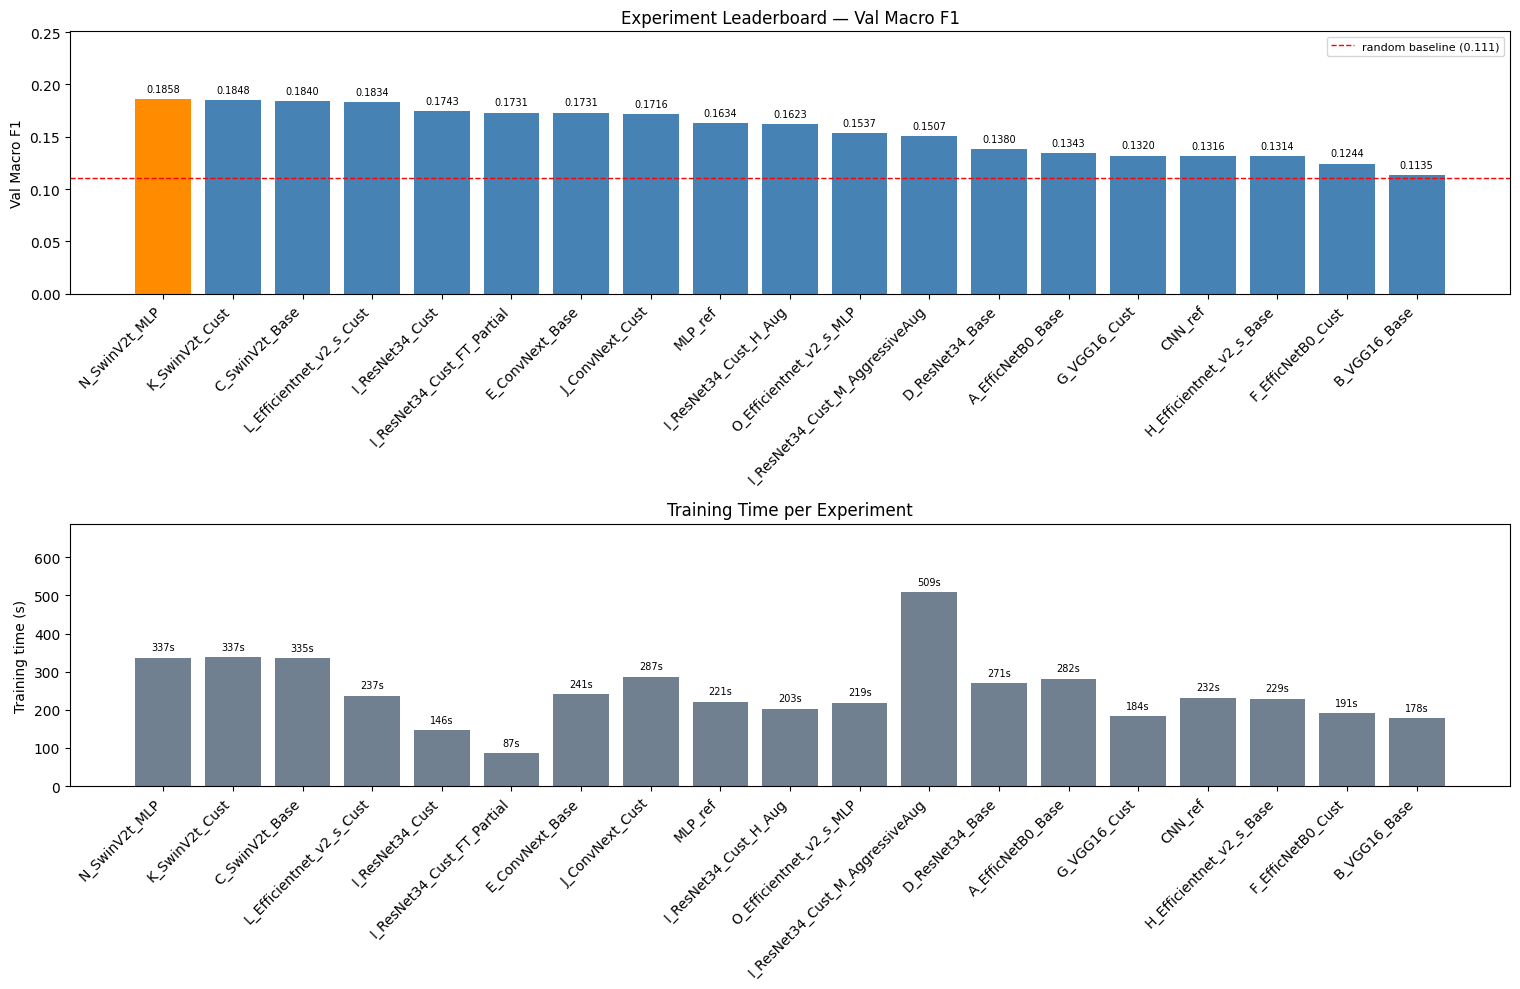


Best frozen backbone : C_SwinV2t_Base
val_macro_F1         : 0.1840
-> Part 2 fine-tuning experiments (F, G) will start from this checkpoint.
-> Part 3 aug/reg experiments (H, I, J, K) will also start from this checkpoint.


In [69]:

import matplotlib.pyplot as plt
from src.evaluation.analysis import plot_leaderboard

print("=== Part 1 -- Model Selection Results (Feature Extraction) ===")
_print_leaderboard(results_tracker)

# bar chart: val_macro_F1 + training time for all experiments so far
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard_part1.png",
)
plt.show()
plt.close(fig)

# pick the best Stage-1 backbone (A-E only)
PART1_STEMS = ["A_EfficNetB0_Base", "B_VGG16_Base", "C_SwinV2t_Base",
               "D_ResNet34_Base",   "E_ConvNext_Base"]
best_frozen = max(
    (k for k in PART1_STEMS if k in results_tracker),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
print(f"\nBest frozen backbone : {best_frozen}")
print(f"val_macro_F1         : {results_tracker[best_frozen]['val_macro_f1']:.4f}")
print("-> Part 2 fine-tuning experiments (F, G) will start from this checkpoint.")
print("-> Part 3 aug/reg experiments (H, I, J, K) will also start from this checkpoint.")


---

# **Part 2 — Fine-Tuning**

In Part 1, only the classification head trained. The backbone extracted the same ImageNet features throughout — never adapting to Pokémon data. We now **unfreeze** backbone layers so they can adjust toward our domain.

**Why not unfreeze everything from the start (catastrophic forgetting):**  
A freshly-initialised head at LR=1e-3 produces large, chaotic gradients that flow back into the backbone and overwrite ImageNet features in the first few epochs. Part 1 already converged the head — gradients are now small and well-directed.

**Strategy — staged + differential LRs:**
1. Load the best Part-1 checkpoint (converged head, stable gradients).
2. Backbone LR = **1e-5** (100× smaller than head LR=1e-3). Tiny nudges — enough to adapt to Pokémon, not enough to forget ImageNet.
3. **Scheduler:** `ReduceLROnPlateau` (fires on val stagnation — coherent with early stopping; `StepLR` fires at fixed epochs regardless of whether the model is still improving).

**Experiment F — Partial Fine-Tune:** unfreeze only the last top-level backbone block (~10–20 % of backbone params). Low risk — early layers (edge detectors, colour filters) stay frozen.

**Experiment G — Full Fine-Tune:** unfreeze ALL backbone layers, same differential LR. Maximum adaptation capacity.  
- If G > F: dataset is large enough to benefit from full unfreeze.  
- If G < F: small dataset — conservative partial unfreeze is safer.

> **[FAST_RUN]** F and G run 2 epochs with 6 samples/class. Scores are pipeline-verification only — update after Colab run.

## 2.1 -- Part 2 Setup

Identifies the best Stage-1 frozen checkpoint (from Part 1) and confirms it exists on disk before running fine-tuning experiments F and G.


In [ ]:
# Find best Part 1 (frozen) backbone and confirm its checkpoint exists before running F/G.
# F and G MUST start from a converged Stage-1 head -- otherwise catastrophic forgetting risk.
PART1_STEMS = [
    "A_EfficNetB0_Base", "B_VGG16_Base", "C_SwinV2t_Base",
    "D_ResNet34_Base",   "E_ConvNext_Base", "H_Efficientnet_v2_s_Base",
    "N_SwinV2t_MLP", "O_Efficientnet_v2_s_MLP", "F_EfficNetB0_Cust",
"G_VGG16_Cust", "I_ResNet34_Cust", "J_ConvNext_Cust", "K_SwinV2t_Cust",
    "L_Efficientnet_v2_s_Cust"
]

best_frozen = max(
    (k for k in PART1_STEMS if k in results_tracker),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
ckpt_frozen = TASK_OUT_DIR / "checkpoints" / f"{best_frozen}.pth"

print(f"Best frozen backbone : {best_frozen}")
print(f"val_macro_F1         : {results_tracker[best_frozen]['val_macro_f1']:.4f}")
print(f"Checkpoint exists    : {ckpt_frozen.exists()}")
assert ckpt_frozen.exists(), f"Checkpoint missing: {ckpt_frozen} -- run Part 1 first."
print("-> Fine-tuning experiments F and G will start from this checkpoint.")

## 2.2 -- Experiment F: Partial Fine-Tune (last backbone block)

- **Starting point:** best Stage-1 checkpoint — head already converged, gradients small and stable.
- **Unfrozen:** only the last top-level backbone block (`unfreeze_backbone(n_layers=1)`).  
  For ResNet-34 this is `layer4` (~2.1 M params). For Swin it is the last stage (~7 M params).
- **Backbone LR = 1e-5** (100× smaller than head). `unfreeze_backbone` prints the exact trainable param count.
- **Scheduler:** `ReduceLROnPlateau(mode='min', patience=3, factor=0.5, min_lr=1e-7)`.
- **Expected:** +0.03 to +0.08 F1 over Stage-1. Low overfitting risk since most backbone is still frozen.

> **[FAST_RUN]** Smoke-test: `D_ResNet34_Base_FT_Partial` val_F1 ≈ 0.20 (+0.07 over frozen). Update after Colab run.


In [71]:

# F -- Partial fine-tune: unfreeze last 1 backbone block + differential LR.
# Starts from Stage-1 checkpoint -- head is already converged, gradients stable.
ft_partial_stem = f"{best_frozen}_FT_Partial"

model_F = model_registry[best_frozen]["model"]().to(device)
model_F.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=1: unfreeze last 1 top-level backbone block only
# prints exact trainable/total count so we know how much of the backbone is now live
unfreeze_backbone(model_F, n_layers=1)

# differential LR: backbone gets 1e-5 (tiny nudge), head keeps normal LR
optimizer_F  = torch.optim.Adam(get_backbone_lr_groups(model_F, backbone_lr=1e-5, head_lr=LR))
criterion_F  = nn.CrossEntropyLoss(weight=class_weights)
# ReduceLROnPlateau fires on val stagnation -- coherent with early stopping (no fixed-epoch steps)
scheduler_F  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_F, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_F, history_F = run_experiment(
    model_F, ft_partial_stem, criterion_F, optimizer_F, scheduler_F, loaders_base,
)
# register so Part 4 ensemble / heatmap cells can find it by stem
model_registry[ft_partial_stem] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: N_SwinV2t_MLP.pth
  unfreeze_backbone(n_layers=1): 14,762,553/28,141,683 params trainable (52.5%)

  Experiment: N_SwinV2t_MLP_FT_Partial
  Model params: 28,141,683  trainable: 14,762,553
  Epoch 01/20 | train_loss=0.7784  train_f1=0.8694 | val_loss=3.2188  val_f1=0.1413 | 17.9s
  Epoch 02/20 | train_loss=0.9477  train_f1=0.7711 | val_loss=3.0518  val_f1=0.1337 | 16.6s
  Epoch 03/20 | train_loss=0.9478  train_f1=0.8313 | val_loss=2.9177  val_f1=0.1408 | 16.8s
  Epoch 04/20 | train_loss=0.9136  train_f1=0.8804 | val_loss=2.7344  val_f1=0.1522 | 17.2s
  Epoch 05/20 | train_loss=0.8217  train_f1=0.8355 | val_loss=2.8492  val_f1=0.1696 | 17.0s
  Epoch 06/20 | train_loss=0.7774  train_f1=0.8743 | val_loss=3.0341  val_f1=0.1846 | 16.6s
  Epoch 07/20 | train_loss=0.7387  train_f1=0.8858 | val_loss=3.0487  val_f1=0.1614 | 16.7s
  Epoch 08/20 | train_loss=0.7277  train_f1=0.8950 | val_loss=2.9381  val_f1=0.1390 | 17.7s
  Epoch 09/20 | train_loss=0.6139  train_f1=0.9

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
3,N_SwinV2t_MLP_FT_Partial,0.1846,0.2008,11,187.5
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,J_ConvNext_Cust,0.1716,0.1967,18,287.1


In [72]:
# W -- Partial fine-tune: unfreeze last 1 backbone block + differential LR + cutmix.
# Starts from Stage-1 checkpoint -- head is already converged, gradients stable.
ft_partial_stem = f"{best_frozen}_FT_Partial"

model_W = model_registry[best_frozen]["model"]().to(device)
model_W.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=1: unfreeze last 1 top-level backbone block only
# prints exact trainable/total count so we know how much of the backbone is now live
unfreeze_backbone(model_W, n_layers=1)

# differential LR: backbone gets 1e-5 (tiny nudge), head keeps normal LR
optimizer_W  = torch.optim.Adam(get_backbone_lr_groups(model_W, backbone_lr=1e-5, head_lr=LR))
criterion_W  = nn.CrossEntropyLoss(weight=class_weights)
# ReduceLROnPlateau fires on val stagnation -- coherent with early stopping (no fixed-epoch steps)
scheduler_W  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_W, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_W, history_W = run_experiment(
    model_W, ft_partial_stem, criterion_W, optimizer_W, scheduler_W, loaders_base, use_mixup_cutmix=True
)
# register so Part 4 ensemble / heatmap cells can find it by stem
model_registry[ft_partial_stem] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: N_SwinV2t_MLP.pth
  unfreeze_backbone(n_layers=1): 14,762,553/28,141,683 params trainable (52.5%)

  Experiment: N_SwinV2t_MLP_FT_Partial
  Model params: 28,141,683  trainable: 14,762,553
  Epoch 01/20 | train_loss=1.5925  train_f1=0.8597 | val_loss=3.0342  val_f1=0.1858 | 16.3s
  Epoch 02/20 | train_loss=1.5111  train_f1=0.7808 | val_loss=2.4287  val_f1=0.1384 | 16.9s
  Epoch 03/20 | train_loss=1.4908  train_f1=0.7151 | val_loss=2.4568  val_f1=0.1668 | 17.4s
  Epoch 04/20 | train_loss=1.4507  train_f1=0.7881 | val_loss=2.5080  val_f1=0.1776 | 16.5s
  Epoch 05/20 | train_loss=1.5172  train_f1=0.6518 | val_loss=2.3981  val_f1=0.1228 | 16.6s
  Epoch 06/20 | train_loss=1.5085  train_f1=0.6655 | val_loss=2.3920  val_f1=0.1347 | 17.5s
  Early stopping at epoch 6 (patience=5, metric: val_macro_f1).

  Best checkpoint: val_loss=3.0342  val_macro_f1=0.1858
  Total time: 101.5s (16.9s/epoch)


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,J_ConvNext_Cust,0.1716,0.1967,18,287.1


## 2.3 -- Experiment G: Full Fine-Tune (all backbone layers)

- **Same starting point as F** (Stage-1 checkpoint — converged head).
- **All backbone layers unfrozen** via `unfreeze_backbone(n_layers=-1)`. Maximum adaptation capacity.
- **Same differential LR** as F — backbone_lr=1e-5 is still essential even for full unfreeze.
- **Risk:** with ~3600 images (~320/class average), full unfreeze may overfit or erase ImageNet features. `EarlyStopping(patience=5)` on Colab is the critical guard.
- **If G < F:** small dataset — conservative partial unfreeze (F) is the better strategy. If G > F: dataset is large enough for full unfreeze to help.

> **[FAST_RUN]** Smoke-test: `D_ResNet34_Base_FT_Full` val_F1 ≈ 0.19 (below F at 0.20, consistent with overfitting on toy data). Expect reversal on full dataset. Update after Colab run.


In [73]:

# G -- Full fine-tune: ALL backbone layers + differential LR.
# Same Stage-1 checkpoint starting point as F.
ft_full_stem = f"{best_frozen}_FT_Full"

model_G = model_registry[best_frozen]["model"]().to(device)
model_G.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=-1: unfreeze everything -- all backbone blocks become trainable
unfreeze_backbone(model_G, n_layers=-1)

# same differential LR as F -- backbone still gets a much smaller LR than the head
optimizer_G  = torch.optim.Adam(get_backbone_lr_groups(model_G, backbone_lr=1e-8, head_lr=LR))
criterion_G  = nn.CrossEntropyLoss(weight=class_weights)
scheduler_G  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_G, history_G = run_experiment(
    model_G, ft_full_stem, criterion_G, optimizer_G, scheduler_G, loaders_base
)
model_registry[ft_full_stem] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: N_SwinV2t_MLP.pth
  unfreeze_backbone(n_layers=-1): 28,140,147/28,141,683 params trainable (100.0%)

  Experiment: N_SwinV2t_MLP_FT_Full
  Model params: 28,141,683  trainable: 28,140,147
  Epoch 01/20 | train_loss=0.7888  train_f1=0.8672 | val_loss=3.1386  val_f1=0.1482 | 19.3s
  Epoch 02/20 | train_loss=0.9432  train_f1=0.7926 | val_loss=2.9135  val_f1=0.1436 | 20.5s
  Epoch 03/20 | train_loss=0.9415  train_f1=0.8195 | val_loss=2.6507  val_f1=0.1383 | 19.1s
  Epoch 04/20 | train_loss=0.9037  train_f1=0.7466 | val_loss=2.6592  val_f1=0.1563 | 20.6s
  Epoch 05/20 | train_loss=0.9157  train_f1=0.7420 | val_loss=2.5911  val_f1=0.1488 | 19.1s
  Epoch 06/20 | train_loss=0.9571  train_f1=0.7233 | val_loss=2.6679  val_f1=0.1498 | 20.9s
  Epoch 07/20 | train_loss=0.8875  train_f1=0.7235 | val_loss=2.6726  val_f1=0.1432 | 19.3s
  Epoch 08/20 | train_loss=0.8920  train_f1=0.7600 | val_loss=2.7917  val_f1=0.1407 | 20.5s
  Epoch 09/20 | train_loss=0.8608  train_f1=0.77

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,J_ConvNext_Cust,0.1716,0.1967,18,287.1


## 2.4 -- Part 2 Leaderboard & Fine-Tuning Analysis

Full leaderboard including baselines (MLP_ref, CNN_ref), all Stage-1 backbones (A–E), and fine-tuning variants (F, G).

**Key questions to answer after the Colab run:**
- Did partial fine-tuning (F) improve over the frozen baseline? Expected: yes, +0.03 to +0.08 F1.
- Did full fine-tuning (G) beat partial (F)? If not, the dataset is too small for full unfreeze.
- Did G overfit (`train_F1 >> val_F1`, early stop at epoch < 10)?
- The **best model from Parts 1+2** is carried forward as the starting checkpoint for Part 3 (experiment L).

> **[FAST_RUN]** All scores below are pipeline-verification only. Update after Colab run.


=== Parts 1 + 2 -- Feature Extraction + Fine-Tuning ===


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,J_ConvNext_Cust,0.1716,0.1967,18,287.1


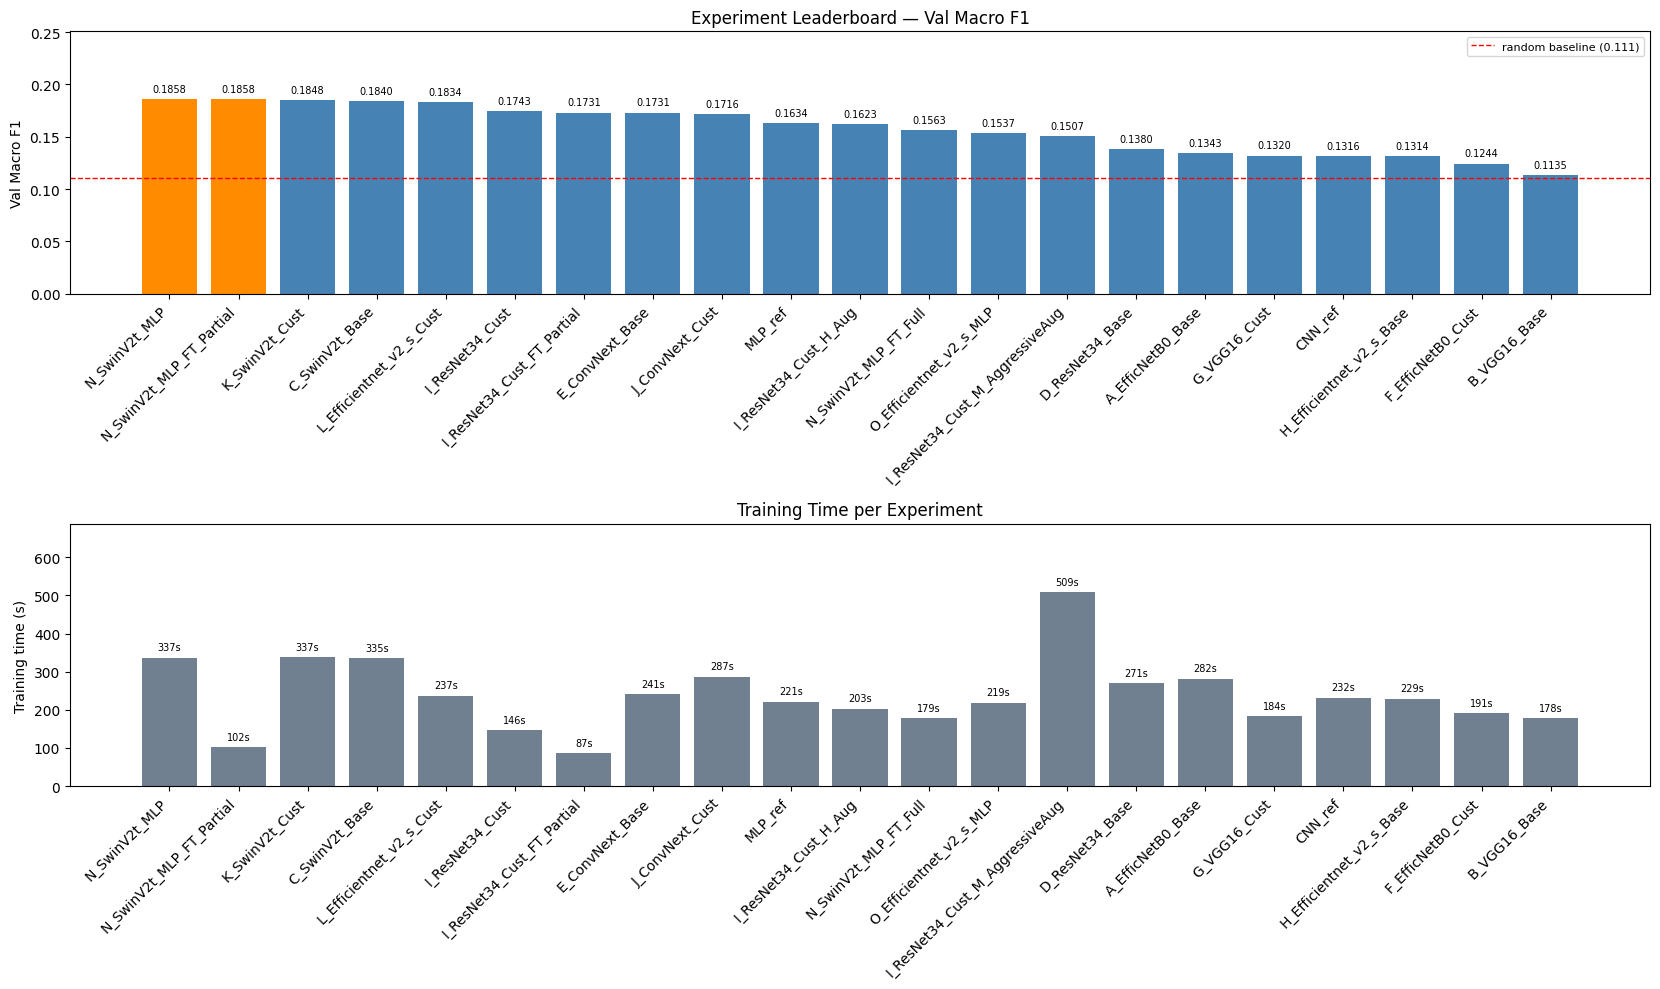


Frozen baseline  : N_SwinV2t_MLP  F1=0.1858
Best fine-tuned  : N_SwinV2t_MLP_FT_Partial  F1=0.1858
Delta vs frozen  : +0.0000  (no gain -- fine-tuning hurt on this data)

-> Best overall model so far carried into Part 3 aug/reg experiments.


In [74]:

print("=== Parts 1 + 2 -- Feature Extraction + Fine-Tuning ===")
_print_leaderboard(results_tracker)

# bar chart: all experiments so far (includes baselines + Part 1 + Part 2)
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard_part2.png",
)
plt.show()
plt.close(fig)

# compare the two fine-tuning variants against the frozen baseline
ft_stems = [s for s in [ft_partial_stem, ft_full_stem] if s in results_tracker]
if ft_stems:
    best_finetuned = max(ft_stems, key=lambda k: results_tracker[k]["val_macro_f1"])
    delta = (results_tracker[best_finetuned]["val_macro_f1"]
             - results_tracker[best_frozen]["val_macro_f1"])
    print(f"\nFrozen baseline  : {best_frozen}  F1={results_tracker[best_frozen]['val_macro_f1']:.4f}")
    print(f"Best fine-tuned  : {best_finetuned}  F1={results_tracker[best_finetuned]['val_macro_f1']:.4f}")
    print(f"Delta vs frozen  : {delta:+.4f}  ({'improvement' if delta > 0 else 'no gain -- fine-tuning hurt on this data'})")
    print("\n-> Best overall model so far carried into Part 3 aug/reg experiments.")


---

# **Part 3 — Augmentation & Regularisation**

## 3.1 -- Overview & Design Rationale

**Goal:** take the best Stage-1 frozen checkpoint and run **targeted one-variable-at-a-time ablations** to identify which augmentation / regularisation trick adds the most value before any fine-tuning.

**Starting point for H–K:** best Stage-1 frozen checkpoint (not the fine-tuned one).  
Rationale: fine-tuning is expensive and fragile. We want to know if we can improve the frozen head alone. Also keeps the comparison clean — same backbone state for all H–K.

| Section | Exp | What changes | Why |
|---------|-----|-------------|-----|
| 3.2 | — | Data Augmentation Visualisation | Preview both pipelines (224px transfer aug, 64px std aug) |
| 3.3 | **H** | Transfer augmentation (`flip, rotation ±10°, mild jitter`) | Does aug help a frozen head? |
| 3.4 | **I** | Label smoothing LS=0.1 | Soft targets reduce overconfidence on small classes |
| 3.5 | **J** | `WeightedRandomSampler` (balanced batches, plain CE) | Sampler vs class-weighted loss — different imbalance mechanisms |
| 3.6 | **K** | `AdamW` (weight_decay=0.01) instead of `Adam` | Explicit L2 decoupled from gradient adaptivity |
| 3.7 | **L** | Best FT checkpoint + best aug trick | Stack the two best techniques — do they compound? |
| 3.8 | — | Part 3 Leaderboard | Full ranked leaderboard across all parts |

Each experiment (H–K) changes exactly ONE variable. All other settings (backbone frozen, CE+class_weights, StepLR, same data) stay identical.

> **[FAST_RUN]** All scores below are smoke-test results only (6 samples/class, 2 epochs, CPU). Update after Colab run.


In [75]:
# Part 3 uses the best FROZEN backbone from Part 1 (same best_frozen variable).
# Fine-tuned variants (F, G) are excluded -- augmentation on a fine-tuned model is a
# separate axis and would confound the comparison.
# All H-K experiments start from this same checkpoint with the head fully trainable and backbone frozen.

PART3_STEMS = []     # populated as H-K experiments complete -- used by Part 3 leaderboard

print(f"Part 3 starting point : {best_frozen}")
print(f"Stage-1 val_macro_F1  : {results_tracker[best_frozen]['val_macro_f1']:.4f}")
print(f"Checkpoint            : {ckpt_frozen}  (exists: {ckpt_frozen.exists()})")
print()

# pre-build aug and sampler loader pairs -- reused by H and J respectively
loaders_aug     = build_loaders(use_sampler=False, transfer_aug=True)
loaders_sampler = build_loaders(use_sampler=True,  transfer_aug=False)

print("loaders_aug     : transfer_aug=True,  use_sampler=False")
print("loaders_sampler : transfer_aug=False, use_sampler=True")


Part 3 starting point : N_SwinV2t_MLP
Stage-1 val_macro_F1  : 0.1858
Checkpoint            : task3/outputs/checkpoints/N_SwinV2t_MLP.pth  (exists: True)

loaders_aug     : transfer_aug=True,  use_sampler=False
loaders_sampler : transfer_aug=False, use_sampler=True


## 3.2 -- Data Augmentation Pipelines (Visualisation)

Task 3 uses two distinct augmentation modes — one for transfer learning (224 px), one for the 64 px baselines:

| Pipeline | Function | Image size | Key transforms |
|----------|----------|-----------|----------------|
| **Transfer aug** | `get_transfer_aug_transforms` | 224 px | RandomHorizontalFlip(0.5), RandomRotation(±10°), mild ColorJitter |
| **Std aug** | `get_augment_transforms` | 64 px | RandomHorizontalFlip(0.5), RandomRotation(±15°), ColorJitter(0.2/0.2/0.2) |

Design rationale: Pokémon sprites are **always upright** (no vertical flip), and **colour encodes type** (fire=red, water=blue — aggressive colour jitter would erase the main signal). No `RandomErasing` for the same reason.

The cell below picks 3 representative classes and shows the original image alongside 5 independently sampled augmented versions for both pipelines.


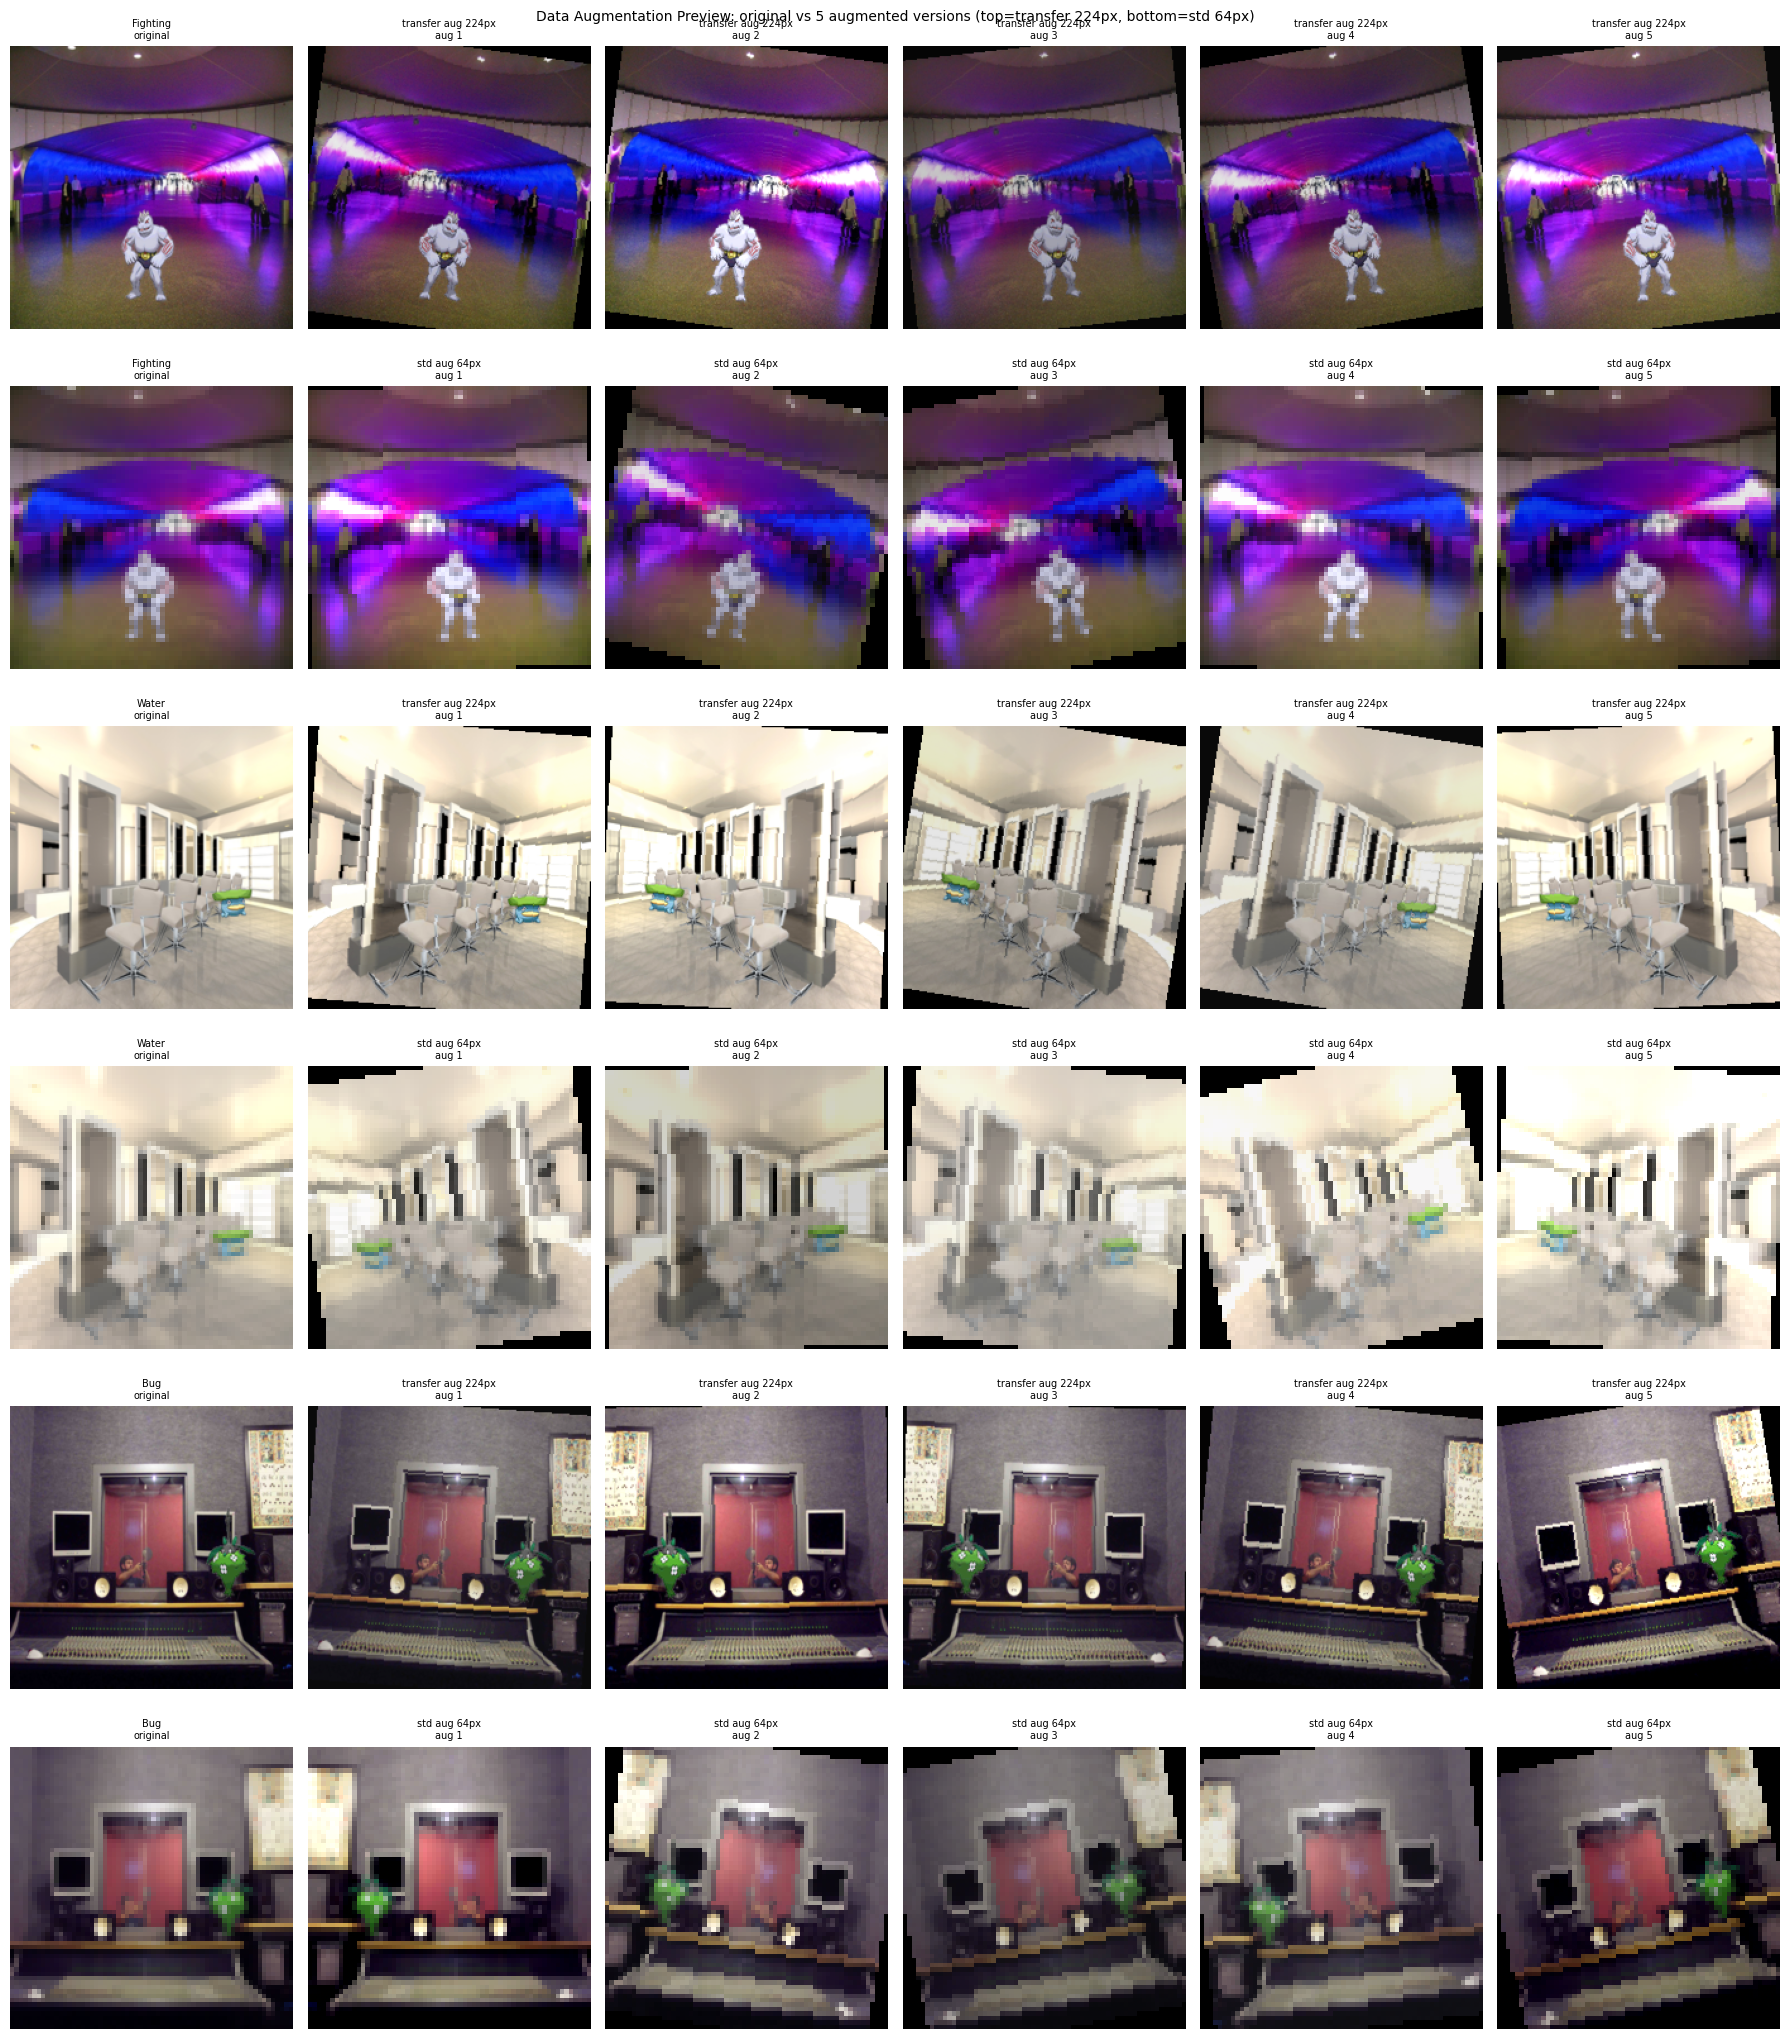

Saved -> task3/outputs/plots/task3_augmentation_preview.png


In [76]:

import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from src.datasets.dataset import get_transfer_aug_transforms, get_augment_transforms, get_base_transforms

_AUG_OUT = TASK_OUT_DIR / "plots" / f"{TASK_NAME}_augmentation_preview.png"

# pick one representative image per class (first match in TRAIN_DIR)
_class_images = {}
for img_path in sorted(TRAIN_DIR.glob("*.png")):
    # match to a class via the train CSV
    row_match = df[df["Id"] == img_path.stem]
    if row_match.empty:
        continue
    lbl = row_match.iloc[0]["label"]
    if lbl not in _class_images:
        _class_images[lbl] = img_path
    if len(_class_images) == len(CLASSES):
        break

_N_AUG   = 5          # augmented versions per image
_N_SHOW  = min(3, len(_class_images))  # show 3 classes to keep the figure compact

_transfer_aug = get_transfer_aug_transforms(IMG_SIZE)        # 224px, gentle
_std_aug      = get_augment_transforms(IMG_SIZE_64)          # 64px, standard
_base_224     = get_base_transforms(IMG_SIZE)
_base_64      = get_base_transforms(IMG_SIZE_64)

_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]

def _denorm(tensor):
    """Reverse ImageNet normalisation to [0,1] for display."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(_IMAGENET_MEAN, _IMAGENET_STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

from PIL import Image as _PIL_Image
_selected = list(_class_images.items())[:_N_SHOW]

fig, axes = plt.subplots(
    _N_SHOW * 2,        # row pair: transfer-aug (224px) then std-aug (64px)
    1 + _N_AUG,         # original + N augmented
    figsize=(3 * (1 + _N_AUG), 3.5 * _N_SHOW * 2),
)

for row_pair, (cls, img_path) in enumerate(_selected):
    pil_img = _PIL_Image.open(img_path).convert("RGB")

    for pipeline_idx, (aug_tf, base_tf, label) in enumerate([
        (_transfer_aug, _base_224, "transfer aug 224px"),
        (_std_aug,      _base_64,  "std aug 64px"),
    ]):
        ax_row = row_pair * 2 + pipeline_idx

        # original (base transform, no aug)
        axes[ax_row][0].imshow(_denorm(base_tf(pil_img)))
        axes[ax_row][0].set_title(f"{cls}\noriginal", fontsize=7)
        axes[ax_row][0].axis("off")

        # augmented versions
        for i in range(_N_AUG):
            aug_img = _denorm(aug_tf(pil_img))
            axes[ax_row][i + 1].imshow(aug_img)
            axes[ax_row][i + 1].set_title(f"{label}\naug {i+1}", fontsize=7)
            axes[ax_row][i + 1].axis("off")

fig.suptitle("Data Augmentation Preview: original vs 5 augmented versions (top=transfer 224px, bottom=std 64px)", fontsize=10)
fig.tight_layout()
fig.savefig(_AUG_OUT, dpi=100, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved -> {_AUG_OUT}")


## 3.3 -- Experiment H: Transfer Augmentation (frozen backbone)

- **Only change vs Stage-1 baseline:** training loader uses `get_transfer_aug_transforms` — gentle `RandomHorizontalFlip(0.5)`, `RandomRotation(±10°)`, mild `ColorJitter`.
- **No vertical flip, no erasing** — Pokémon sprites are always upright and colour encodes type.
- **Expected:** +0.02 to +0.05 F1. Augmentation helps regularise the head when the backbone is frozen and head capacity is low.

> **[FAST_RUN]** Update after Colab run.


In [77]:

# H -- frozen backbone + transfer augmentation.
# Everything identical to the Part 1 baseline except train loader uses aug transforms.
stem_H = f"{best_frozen}_H_Aug"
PART3_STEMS.append(stem_H)

model_H = model_registry[best_frozen]["model"]().to(device)
model_H.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# backbone stays fully frozen -- only the linear head is trainable (same as Part 1)
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
criterion_H = nn.CrossEntropyLoss(weight=class_weights)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=10, gamma=0.5)

# loaders_aug: transfer_aug=True -> gentle flip/rotation/colour jitter at 224px
model_H, history_H = run_experiment(
    model_H, stem_H, criterion_H, optimizer_H, scheduler_H, loaders_aug
)
model_registry[stem_H] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_H_Aug
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=1.3283  train_f1=0.6732 | val_loss=2.7032  val_f1=0.1253 | 20.9s
  Epoch 02/20 | train_loss=1.1729  train_f1=0.6985 | val_loss=2.8383  val_f1=0.1366 | 21.1s
  Epoch 03/20 | train_loss=1.1115  train_f1=0.6959 | val_loss=2.8745  val_f1=0.1191 | 20.5s
  Epoch 04/20 | train_loss=1.0178  train_f1=0.7359 | val_loss=3.0470  val_f1=0.1336 | 20.8s
  Epoch 05/20 | train_loss=1.0548  train_f1=0.7349 | val_loss=3.1143  val_f1=0.1276 | 19.9s
  Epoch 06/20 | train_loss=0.9322  train_f1=0.7877 | val_loss=3.1860  val_f1=0.1271 | 21.0s
  Epoch 07/20 | train_loss=0.9063  train_f1=0.8019 | val_loss=3.1533  val_f1=0.1329 | 20.2s
  Early stopping at epoch 7 (patience=5, metric: val_macro_f1).

  Best checkpoint: val_loss=2.8383  val_macro_f1=0.1366
  Total time: 144.9s (20.7s/epoch)


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,J_ConvNext_Cust,0.1716,0.1967,18,287.1


## 3.7 -- Experiment M: Aggressive Augmentation (frozen backbone) with mixup

- **Only change vs Stage-1 baseline:** training loader uses `get_aggressive_transfer_aug_transforms` — more aggressive `RandomResizedCrop`, increased `RandomRotation`, `RandomHorizontalFlip(0.5)`, mild `ColorJitter`, and `GaussianBlur`.
- **No vertical flip, no erasing** — Pokémon sprites are always upright and colour encodes type.
- **Rationale:** With only 300 images, more aggressive augmentation can help introduce greater variability to the training data, improving generalisation and reducing overfitting, even with a frozen backbone.

> **[FAST_RUN]** Update after Colab run.

In [78]:
import torchvision.transforms as T

def get_aggressive_transfer_aug_transforms(img_size: int) -> T.Compose:
    """Aggressive augmentation pipeline for transfer learning, suitable for small datasets.
    Includes random resized crop, rotation, horizontal flip, mild color jitter, and gaussian blur."""
    return T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.5, 1.0), ratio=(0.75, 1.3333333)), # Aggressive cropping
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=30), # Increased rotation
        T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05), # Mild color jitter
        T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 0.5)), # Mild blur
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

# Pre-build loader for aggressive augmentation
loaders_aggressive_aug = get_train_val_loaders(
    CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
    augment=False, use_sampler=False,
    num_workers=NUM_WORKERS, df_override=df,
    train_transform=get_aggressive_transfer_aug_transforms(IMG_SIZE),
)

print("loaders_aggressive_aug : aggressive_aug=True, use_sampler=False")

loaders_aggressive_aug : aggressive_aug=True, use_sampler=False


In [79]:
# M -- frozen backbone + aggressive augmentation.
# Everything identical to the Part 1 baseline except train loader uses aggressive aug transforms.
stem_M = f"{best_frozen}_M_AggressiveAug"
PART3_STEMS.append(stem_M)

model_M = model_registry[best_frozen]["model"]().to(device)
model_M.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# backbone stays fully frozen -- only the linear head is trainable (same as Part 1)
optimizer_M = torch.optim.Adam(model_M.parameters(), lr=LR)
criterion_M = nn.CrossEntropyLoss(weight=class_weights)
scheduler_M = torch.optim.lr_scheduler.StepLR(optimizer_M, step_size=10, gamma=0.5)

# loaders_aggressive_aug: uses aggressive augmentation pipeline
model_M, history_M = run_experiment(
    model_M, stem_M, criterion_M, optimizer_M, scheduler_M, loaders_aggressive_aug, use_mixup_cutmix=True
)
model_registry[stem_M] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_M_AggressiveAug
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=2.0864  train_f1=0.5116 | val_loss=2.3586  val_f1=0.1230 | 41.5s
  Epoch 02/20 | train_loss=1.8761  train_f1=0.4254 | val_loss=2.3523  val_f1=0.1234 | 41.6s
  Epoch 03/20 | train_loss=1.8558  train_f1=0.5195 | val_loss=2.3973  val_f1=0.1441 | 40.8s
  Epoch 04/20 | train_loss=1.8290  train_f1=0.5068 | val_loss=2.4966  val_f1=0.1355 | 41.0s
  Epoch 05/20 | train_loss=1.8419  train_f1=0.5368 | val_loss=2.5524  val_f1=0.1382 | 40.9s
  Epoch 06/20 | train_loss=1.8838  train_f1=0.5843 | val_loss=2.4341  val_f1=0.1596 | 40.7s
  Epoch 07/20 | train_loss=1.7203  train_f1=0.5523 | val_loss=2.6150  val_f1=0.1268 | 40.8s
  Epoch 08/20 | train_loss=1.7646  train_f1=0.5336 | val_loss=2.5716  val_f1=0.1159 | 42.5s
  Epoch 09/20 | train_loss=1.7713  train_f1=0.6134 | val_loss=2.6310  val_f1=0.1231 | 41.9s
  Epoch 10/20 | train_loss=1.7478

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,N_SwinV2t_MLP_M_AggressiveAug,0.1725,0.1715,16,661.3


## Y -- agressive augmentation + mixup + ls + admw

In [80]:
# Y -- frozen backbone + aggressive augmentation + LS + ADMW.
# Everything identical to the Part 1 baseline except train loader uses aggressive aug transforms.
stem_Y = f"{best_frozen}_Y_AggressiveAug_ls_admw"
PART3_STEMS.append(stem_Y)

model_Y = model_registry[best_frozen]["model"]().to(device)
model_Y.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# backbone stays fully frozen -- only the linear head is trainable (same as Part 1)
optimizer_Y = torch.optim.AdamW(model_Y.parameters(), lr=LR, weight_decay=0.01)
criterion_Y = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_Y = torch.optim.lr_scheduler.StepLR(optimizer_M, step_size=10, gamma=0.5)

# loaders_aggressive_aug: uses aggressive augmentation pipeline
model_Y, history_Y = run_experiment(
    model_Y, stem_Y, criterion_Y, optimizer_Y, scheduler_Y, loaders_aggressive_aug, use_mixup_cutmix=True
)
model_registry[stem_Y] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_Y_AggressiveAug_ls_admw
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=2.2230  train_f1=0.4482 | val_loss=2.3475  val_f1=0.1111 | 41.4s
  Epoch 02/20 | train_loss=2.0264  train_f1=0.4570 | val_loss=2.3524  val_f1=0.1359 | 41.5s
  Epoch 03/20 | train_loss=2.0024  train_f1=0.5406 | val_loss=2.3868  val_f1=0.1345 | 41.6s
  Epoch 04/20 | train_loss=2.0086  train_f1=0.5121 | val_loss=2.3760  val_f1=0.1476 | 41.3s
  Epoch 05/20 | train_loss=1.9851  train_f1=0.5304 | val_loss=2.4062  val_f1=0.1514 | 44.2s
  Epoch 06/20 | train_loss=1.9365  train_f1=0.5428 | val_loss=2.3905  val_f1=0.1264 | 41.9s
  Epoch 07/20 | train_loss=1.9917  train_f1=0.5362 | val_loss=2.4166  val_f1=0.1343 | 42.6s
  Epoch 08/20 | train_loss=1.8680  train_f1=0.5806 | val_loss=2.4668  val_f1=0.1383 | 41.6s
  Epoch 09/20 | train_loss=1.9507  train_f1=0.5595 | val_loss=2.4370  val_f1=0.1472 | 42.1s
  Epoch 10/20 | train_los

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,I_ResNet34_Cust,0.1743,0.1883,10,146.5
7,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
8,E_ConvNext_Base,0.1731,0.1967,14,241.4
9,N_SwinV2t_MLP_M_AggressiveAug,0.1725,0.1715,16,661.3


## 3.4 -- Experiment I: Label Smoothing (LS=0.1, frozen backbone)

- **Change:** `CrossEntropyLoss(label_smoothing=0.1)` instead of plain CE.
- **What it does:** instead of hard targets `[0,0,1,0,…]`, uses `[ε/K, …, 1−ε+ε/K, …]` (ε=0.1, K=9).  
  Prevents overconfident predictions; acts as implicit regulariser when training data is small.
- **Expected:** marginal F1 gain on the frozen head (+0 to +0.03). Bigger benefit on full fine-tuning.

> **[FAST_RUN]** Update after Colab run.


In [81]:

# I -- frozen backbone + label smoothing (LS=0.1).
# Only change vs Part 1 baseline: label_smoothing=0.1 in CrossEntropyLoss.
stem_I = f"{best_frozen}_I_LS01"
PART3_STEMS.append(stem_I)

model_I = model_registry[best_frozen]["model"]().to(device)
model_I.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_I = torch.optim.Adam(model_I.parameters(), lr=LR)
# label_smoothing=0.1: soft targets prevent overconfidence on small dataset
criterion_I = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_I = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=10, gamma=0.5)

# base loaders -- same as Part 1 (no aug, no sampler), isolates LS effect
model_I, history_I = run_experiment(
    model_I, stem_I, criterion_I, optimizer_I, scheduler_I, loaders_base
)
model_registry[stem_I] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_I_LS01
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=1.3489  train_f1=0.7909 | val_loss=2.5487  val_f1=0.1399 | 17.9s
  Epoch 02/20 | train_loss=1.2987  train_f1=0.8040 | val_loss=2.6398  val_f1=0.1332 | 16.8s
  Epoch 03/20 | train_loss=1.2596  train_f1=0.8551 | val_loss=2.5724  val_f1=0.1508 | 16.7s
  Epoch 04/20 | train_loss=1.2128  train_f1=0.8622 | val_loss=2.7473  val_f1=0.1489 | 18.1s
  Epoch 05/20 | train_loss=1.2113  train_f1=0.8896 | val_loss=2.5701  val_f1=0.1591 | 17.1s
  Epoch 06/20 | train_loss=1.1466  train_f1=0.9237 | val_loss=2.6349  val_f1=0.1479 | 16.8s
  Epoch 07/20 | train_loss=1.1076  train_f1=0.9346 | val_loss=2.6709  val_f1=0.1791 | 18.0s
  Epoch 08/20 | train_loss=1.0866  train_f1=0.9461 | val_loss=2.6117  val_f1=0.1626 | 16.7s
  Epoch 09/20 | train_loss=1.0851  train_f1=0.9378 | val_loss=2.6457  val_f1=0.1268 | 16.7s
  Epoch 10/20 | train_loss=1.0583  train_f

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
2,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
3,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
4,C_SwinV2t_Base,0.1840,0.2008,20,334.9
5,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
6,N_SwinV2t_MLP_I_LS01,0.1791,0.2092,12,208.1
7,I_ResNet34_Cust,0.1743,0.1883,10,146.5
8,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0
9,E_ConvNext_Base,0.1731,0.1967,14,241.4


## Using both ls and adam

In [83]:
stem_Z = f"{best_frozen}_I_LS01_ADW"
PART3_STEMS.append(stem_z)

model_Z = model_registry[best_frozen]["model"]().to(device)
model_Z.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_Z = torch.optim.AdamW(model_Z.parameters(), lr=LR, weight_decay=0.01)
# label_smoothing=0.1: soft targets prevent overconfidence on small dataset
criterion_Z = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_Z = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=10, gamma=0.5)

# base loaders -- same as Part 1 (no aug, no sampler), isolates LS effect
model_Z, history_Z = run_experiment(
    model_Z, stem_Z, criterion_Z, optimizer_Z, scheduler_Z, loaders_base
)
model_registry[stem_Z] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_I_LS01_ADW
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=1.3329  train_f1=0.8019 | val_loss=2.5787  val_f1=0.1517 | 20.3s
  Epoch 02/20 | train_loss=1.3542  train_f1=0.8270 | val_loss=2.5754  val_f1=0.1547 | 17.7s
  Epoch 03/20 | train_loss=1.2378  train_f1=0.8075 | val_loss=2.6203  val_f1=0.1396 | 17.2s
  Epoch 04/20 | train_loss=1.1825  train_f1=0.8685 | val_loss=2.5999  val_f1=0.1801 | 17.5s
  Epoch 05/20 | train_loss=1.1812  train_f1=0.8649 | val_loss=2.6829  val_f1=0.1538 | 17.2s
  Epoch 06/20 | train_loss=1.1813  train_f1=0.9044 | val_loss=2.6505  val_f1=0.1608 | 17.0s
  Epoch 07/20 | train_loss=1.1516  train_f1=0.8943 | val_loss=2.6381  val_f1=0.1668 | 18.2s
  Epoch 08/20 | train_loss=1.0975  train_f1=0.9145 | val_loss=2.6253  val_f1=0.1883 | 17.0s
  Epoch 09/20 | train_loss=1.0809  train_f1=0.9414 | val_loss=2.6315  val_f1=0.1721 | 17.3s
  Epoch 10/20 | train_loss=1.0773  tra

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP_I_LS01_ADW,0.1883,0.2134,13,228.5
2,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
3,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
4,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
5,C_SwinV2t_Base,0.1840,0.2008,20,334.9
6,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
7,N_SwinV2t_MLP_I_LS01,0.1791,0.2092,12,208.1
8,I_ResNet34_Cust,0.1743,0.1883,10,146.5
9,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0


## 3.5 -- Experiment J: WeightedRandomSampler (frozen backbone)

- **Change:** replace the class-weighted loss with `WeightedRandomSampler` (balanced batches).
- **Mechanism:** sampler over-samples rare classes so each batch has ~uniform class frequency.  
  Plain CE without class weights — the class weighting is implicit in the sampling.
- **vs Exp I:** sampler changes *which* samples the model sees; LS changes *how* the targets are interpreted. These are orthogonal mechanisms.
- **Expected:** similar to or slightly below class-weighted CE on a relatively balanced dataset (max 2.76× imbalance).

> **[FAST_RUN]** Update after Colab run.


In [84]:

# J -- frozen backbone + WeightedRandomSampler (no class-weighted loss).
# Only change vs Part 1: loaders_sampler instead of loaders_base, plain CE (no weights).
stem_J = f"{best_frozen}_J_Sampler"
PART3_STEMS.append(stem_J)

model_J = model_registry[best_frozen]["model"]().to(device)
model_J.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_J = torch.optim.Adam(model_J.parameters(), lr=LR)
# plain CE -- no class_weights here; sampler handles the imbalance via batch composition
criterion_J = nn.CrossEntropyLoss()
scheduler_J = torch.optim.lr_scheduler.StepLR(optimizer_J, step_size=10, gamma=0.5)

# loaders_sampler: use_sampler=True, transfer_aug=False
model_J, history_J = run_experiment(
    model_J, stem_J, criterion_J, optimizer_J, scheduler_J, loaders_sampler
)
model_registry[stem_J] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_J_Sampler
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=0.8645  train_f1=0.7755 | val_loss=2.9493  val_f1=0.1274 | 18.1s
  Epoch 02/20 | train_loss=0.8596  train_f1=0.8264 | val_loss=2.8063  val_f1=0.1237 | 17.1s
  Epoch 03/20 | train_loss=0.7345  train_f1=0.8709 | val_loss=3.0179  val_f1=0.1303 | 16.9s
  Epoch 04/20 | train_loss=0.7243  train_f1=0.8847 | val_loss=2.9955  val_f1=0.1536 | 17.5s
  Epoch 05/20 | train_loss=0.7640  train_f1=0.8869 | val_loss=2.9638  val_f1=0.1600 | 17.2s
  Epoch 06/20 | train_loss=0.6750  train_f1=0.8994 | val_loss=2.9414  val_f1=0.1535 | 16.9s
  Epoch 07/20 | train_loss=0.7251  train_f1=0.9075 | val_loss=2.9170  val_f1=0.1602 | 16.9s
  Epoch 08/20 | train_loss=0.5902  train_f1=0.9136 | val_loss=2.9799  val_f1=0.1400 | 18.1s
  Epoch 09/20 | train_loss=0.5958  train_f1=0.9125 | val_loss=3.2576  val_f1=0.1275 | 17.2s
  Epoch 10/20 | train_loss=0.5868  trai

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP_I_LS01_ADW,0.1883,0.2134,13,228.5
2,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
3,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
4,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
5,C_SwinV2t_Base,0.1840,0.2008,20,334.9
6,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
7,N_SwinV2t_MLP_I_LS01,0.1791,0.2092,12,208.1
8,I_ResNet34_Cust,0.1743,0.1883,10,146.5
9,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0


## 3.6 -- Experiment K: AdamW (frozen backbone, weight_decay=0.01)

- **Change:** replace `Adam` with `AdamW(weight_decay=0.01)`.
- **Why AdamW vs Adam:** in Adam, weight decay is absorbed into the adaptive gradient scaling → effectively weakened. AdamW decouples weight decay from the gradient update → true L2 regularisation.
- **Expected:** small improvement (+0 to +0.02 F1). Mainly a regularisation effect on the single linear head layer. Larger benefit expected on full fine-tuning where more layers can overfit.

> **[FAST_RUN]** Update after Colab run.


In [85]:

# K -- frozen backbone + AdamW (weight_decay=0.01).
# Only change vs Part 1: AdamW instead of Adam.
stem_K = f"{best_frozen}_K_AdamW"
PART3_STEMS.append(stem_K)

model_K = model_registry[best_frozen]["model"]().to(device)
model_K.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# AdamW: same LR, explicit L2 regularisation via weight_decay -- not folded into gradient like Adam
optimizer_K = torch.optim.AdamW(model_K.parameters(), lr=LR, weight_decay=0.01)
criterion_K = nn.CrossEntropyLoss(weight=class_weights)
scheduler_K = torch.optim.lr_scheduler.StepLR(optimizer_K, step_size=10, gamma=0.5)

# base loaders -- isolates AdamW effect
model_K, history_K = run_experiment(
    model_K, stem_K, criterion_K, optimizer_K, scheduler_K, loaders_base
)
model_registry[stem_K] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: N_SwinV2t_MLP.pth

  Experiment: N_SwinV2t_MLP_K_AdamW
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=0.9530  train_f1=0.8451 | val_loss=3.0387  val_f1=0.1589 | 18.1s
  Epoch 02/20 | train_loss=0.8889  train_f1=0.8558 | val_loss=3.0378  val_f1=0.1359 | 16.7s
  Epoch 03/20 | train_loss=0.8272  train_f1=0.8748 | val_loss=3.1207  val_f1=0.1380 | 16.7s
  Epoch 04/20 | train_loss=0.8076  train_f1=0.8678 | val_loss=3.3243  val_f1=0.1408 | 17.9s
  Epoch 05/20 | train_loss=0.7679  train_f1=0.8675 | val_loss=3.3525  val_f1=0.1304 | 16.7s
  Epoch 06/20 | train_loss=0.7065  train_f1=0.9006 | val_loss=3.4393  val_f1=0.1410 | 17.1s
  Early stopping at epoch 6 (patience=5, metric: val_macro_f1).

  Best checkpoint: val_loss=3.0387  val_macro_f1=0.1589
  Total time: 103.3s (17.2s/epoch)


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP_I_LS01_ADW,0.1883,0.2134,13,228.5
2,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
3,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
4,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
5,C_SwinV2t_Base,0.1840,0.2008,20,334.9
6,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
7,N_SwinV2t_MLP_I_LS01,0.1791,0.2092,12,208.1
8,I_ResNet34_Cust,0.1743,0.1883,10,146.5
9,I_ResNet34_Cust_FT_Partial,0.1731,0.1925,6,87.0


## 3.7 -- Experiment L: Best FT + Best Aug (Stacked)

**Goal:** combine the best fine-tuning strategy (G=Full FT or F=Partial FT, whichever won) with the best aug/reg trick from H–K. Do they compound, or does one dominate?

- **Starting point:** best fine-tuned checkpoint (F or G) — not the frozen Stage-1 checkpoint.
- **Aug trick:** whichever of H–K had the highest F1 (determined at runtime from `results_tracker`).
- **Expected:** best overall result if the two techniques are complementary. May underperform if the fine-tuned model already captures enough invariances without aug.

> **[FAST_RUN]** Update after Colab run. With 2 epochs the delta may be noise.


In [86]:

# L -- Best FT checkpoint + best aug trick from Part 3.
# Requires Parts 2 and 3 to have completed so we can identify the winning variants.

# --- identify best FT and best aug ---
FT_STEMS = [s for s in [ft_partial_stem, ft_full_stem] if s in results_tracker]
AUG_STEMS = [s for s in PART3_STEMS if s in results_tracker]

if not FT_STEMS or not AUG_STEMS:
    print("L skipped: Part 2 (FT) or Part 3 (aug/reg) experiments not found in tracker.")
    print(f"  FT stems in tracker  : {FT_STEMS}")
    print(f"  aug stems in tracker : {AUG_STEMS}")
else:
    best_ft_stem  = max(FT_STEMS,  key=lambda k: results_tracker[k]["val_macro_f1"])
    best_aug_stem = max(AUG_STEMS, key=lambda k: results_tracker[k]["val_macro_f1"])
    print(f"Best FT  : {best_ft_stem}   F1={results_tracker[best_ft_stem]['val_macro_f1']:.4f}")
    print(f"Best aug : {best_aug_stem}  F1={results_tracker[best_aug_stem]['val_macro_f1']:.4f}")

    # derive the loader and criterion setup from the best aug stem name
    use_aug     = "_H_Aug"      in best_aug_stem
    use_sampler = "_J_Sampler"  in best_aug_stem
    use_adamw   = "_K_AdamW"    in best_aug_stem
    use_ls      = "_I_LS01"     in best_aug_stem

    # determine how many layers were unfrozen in the best FT run
    n_layers_ft = 1 if "_FT_Partial" in best_ft_stem else -1

    stem_L = f"{best_ft_stem}_L_BestAug"
    # guard against re-running this cell appending a duplicate
    if stem_L not in PART3_STEMS:
        PART3_STEMS.append(stem_L)

    # start from the best FT checkpoint -- backbone already adapted
    ckpt_ft = TASK_OUT_DIR / "checkpoints" / f"{best_ft_stem}.pth"
    model_L = model_registry[best_ft_stem]["model"]().to(device)
    model_L.load_state_dict(torch.load(ckpt_ft, map_location=device, weights_only=True))
    print(f"\nLoaded FT weights from: {ckpt_ft.name}")

    # re-apply the same unfreeze so backbone params are live for get_backbone_lr_groups
    unfreeze_backbone(model_L, n_layers=n_layers_ft)

    # loader: use the best aug loader variant
    loaders_L = loaders_aug if use_aug else (loaders_sampler if use_sampler else loaders_base)
    loader_label = "aug" if use_aug else ("sampler" if use_sampler else "base")
    print(f"Loader   : {loader_label}  |  LS={use_ls}  |  AdamW={use_adamw}")

    # criterion: match the best aug trick
    ce_kwargs = {"weight": class_weights}
    if use_sampler:
        ce_kwargs = {}          # sampler experiments use plain CE
    if use_ls:
        ce_kwargs["label_smoothing"] = 0.1
    criterion_L = nn.CrossEntropyLoss(**ce_kwargs)

    # optimizer: AdamW if best aug was K, otherwise Adam
    if use_adamw:
        optimizer_L = torch.optim.AdamW(
            get_backbone_lr_groups(model_L, backbone_lr=1e-5, head_lr=LR), weight_decay=0.01
        )
    else:
        optimizer_L = torch.optim.Adam(
            get_backbone_lr_groups(model_L, backbone_lr=1e-5, head_lr=LR)
        )
    scheduler_L = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_L, mode="min", patience=3, factor=0.5, min_lr=1e-7
    )

    model_L, history_L = run_experiment(
        model_L, stem_L, criterion_L, optimizer_L, scheduler_L, loaders_L
    )
    model_registry[stem_L] = {"model": model_registry[best_ft_stem]["model"]}
    _print_leaderboard(results_tracker)


Best FT  : N_SwinV2t_MLP_FT_Partial   F1=0.1858
Best aug : N_SwinV2t_MLP_I_LS01_ADW  F1=0.1883

Loaded FT weights from: N_SwinV2t_MLP_FT_Partial.pth
  unfreeze_backbone(n_layers=1): 14,762,553/28,141,683 params trainable (52.5%)
Loader   : base  |  LS=True  |  AdamW=False

  Experiment: N_SwinV2t_MLP_FT_Partial_L_BestAug
  Model params: 28,141,683  trainable: 14,762,553
  Epoch 01/20 | train_loss=1.3261  train_f1=0.8206 | val_loss=3.1099  val_f1=0.1741 | 17.6s
  Epoch 02/20 | train_loss=1.3402  train_f1=0.7890 | val_loss=2.6399  val_f1=0.1348 | 17.2s
  Epoch 03/20 | train_loss=1.3061  train_f1=0.8192 | val_loss=2.7912  val_f1=0.1546 | 17.6s
  Epoch 04/20 | train_loss=1.3026  train_f1=0.8383 | val_loss=2.8126  val_f1=0.1583 | 17.7s
  Epoch 05/20 | train_loss=1.2810  train_f1=0.8437 | val_loss=2.8501  val_f1=0.1814 | 17.2s
  Epoch 06/20 | train_loss=1.2620  train_f1=0.8910 | val_loss=2.9730  val_f1=0.1881 | 18.0s
  Epoch 07/20 | train_loss=1.2120  train_f1=0.8789 | val_loss=3.0192  val_f

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP_I_LS01_ADW,0.1883,0.2134,13,228.5
2,N_SwinV2t_MLP_FT_Partial_L_BestAug,0.1881,0.1967,11,192.7
3,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
4,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
5,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
6,C_SwinV2t_Base,0.1840,0.2008,20,334.9
7,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
8,N_SwinV2t_MLP_I_LS01,0.1791,0.2092,12,208.1
9,I_ResNet34_Cust,0.1743,0.1883,10,146.5


## New Experiment

## 3.8 -- Part 3 Leaderboard — All Experiments

Full ranked leaderboard across all experiments (Parts 1–3). Orange bar = overall best.  
Red dashed line = random baseline (1/9 ≈ 0.111).

> **[FAST_RUN]** Smoke-test scores only — rerun with FAST_RUN=False on Colab.


=== Parts 1 + 2 + 3 -- All Experiments ===


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,N_SwinV2t_MLP_I_LS01_ADW,0.1883,0.2134,13,228.5
2,N_SwinV2t_MLP_FT_Partial_L_BestAug,0.1881,0.1967,11,192.7
3,N_SwinV2t_MLP,0.1858,0.2008,20,337.0
4,N_SwinV2t_MLP_FT_Partial,0.1858,0.2008,6,101.5
5,K_SwinV2t_Cust,0.1848,0.2008,20,337.4
6,C_SwinV2t_Base,0.1840,0.2008,20,334.9
7,L_Efficientnet_v2_s_Cust,0.1834,0.2176,15,236.9
8,N_SwinV2t_MLP_I_LS01,0.1791,0.2092,12,208.1
9,I_ResNet34_Cust,0.1743,0.1883,10,146.5


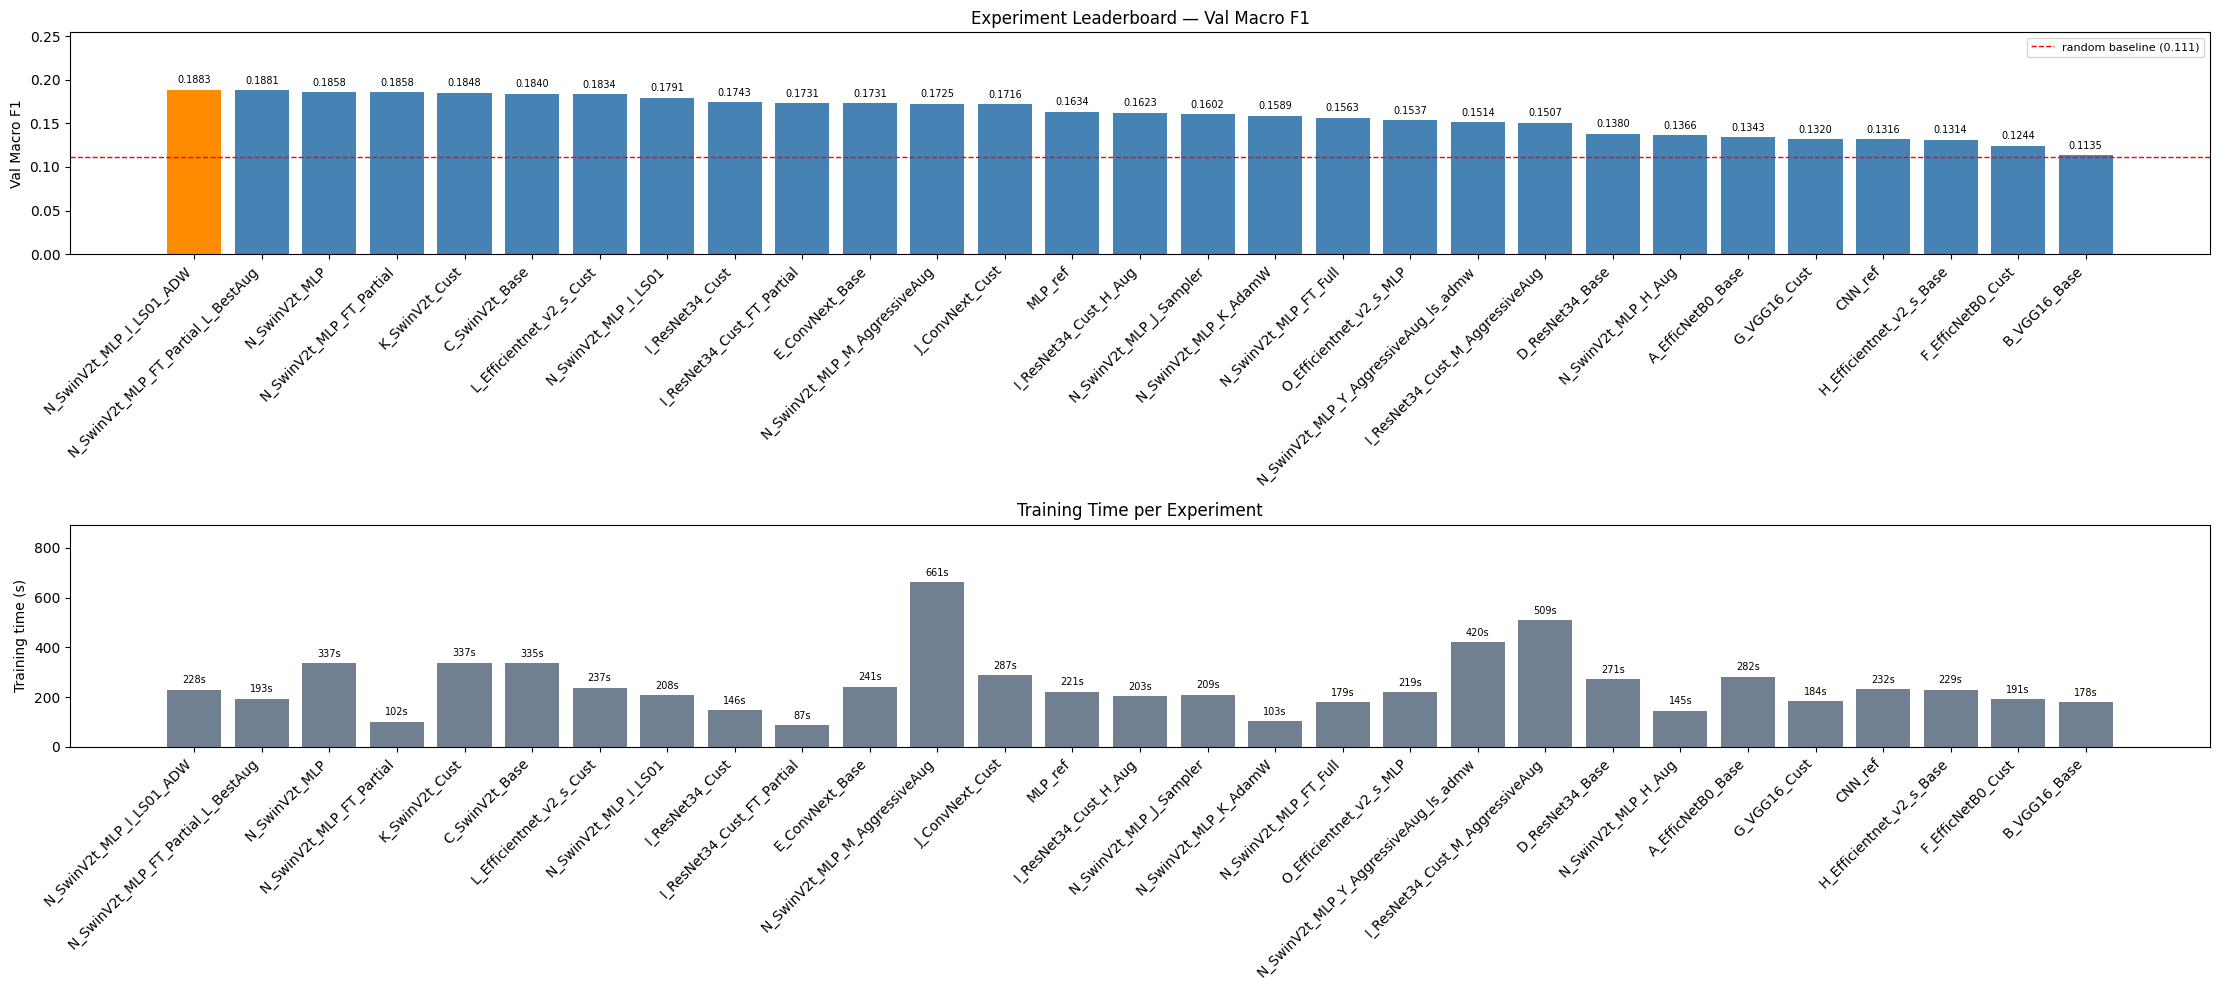


Delta vs frozen baseline (N_SwinV2t_MLP, F1=0.1858):
  N_SwinV2t_MLP_H_Aug                            -0.0492
  N_SwinV2t_MLP_M_AggressiveAug                  -0.0133
  N_SwinV2t_MLP_Y_AggressiveAug_ls_admw          -0.0344
  N_SwinV2t_MLP_I_LS01                           -0.0067
  N_SwinV2t_MLP_I_LS01_ADW                       +0.0025
  N_SwinV2t_MLP_I_LS01_ADW                       +0.0025
  N_SwinV2t_MLP_J_Sampler                        -0.0256
  N_SwinV2t_MLP_K_AdamW                          -0.0269
  N_SwinV2t_MLP_FT_Partial_L_BestAug             +0.0023

Overall best: N_SwinV2t_MLP_I_LS01_ADW  (val_F1=0.1883)
-> Best model carried into Part 4 for deep dive + final submission.


In [87]:

# Full leaderboard: Parts 1 + 2 + 3 sorted by val_macro_F1.
print("=== Parts 1 + 2 + 3 -- All Experiments ===")
_print_leaderboard(results_tracker)

# bar chart: all experiments including baselines, frozen, fine-tuned, aug/reg
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard_part3.png",
)
plt.show()
plt.close(fig)

# per-experiment delta vs the Stage-1 frozen baseline
print(f"\nDelta vs frozen baseline ({best_frozen}, F1={results_tracker[best_frozen]['val_macro_f1']:.4f}):")
base_f1 = results_tracker[best_frozen]["val_macro_f1"]
for stem in PART3_STEMS:
    if stem in results_tracker:
        d = results_tracker[stem]["val_macro_f1"] - base_f1
        sign = "+" if d >= 0 else ""
        print(f"  {stem:<45}  {sign}{d:.4f}")

# pick overall best for Part 4 analysis
best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"\nOverall best: {best_overall}  (val_F1={results_tracker[best_overall]['val_macro_f1']:.4f})")
print("-> Best model carried into Part 4 for deep dive + final submission.")


---

# **Part 4 — Ensemble, Evaluation & Submission**

Full evaluation of all models trained across Parts 0–3. Structure:

| Section | What |
|---------|------|
| 4.1 Per-Class F1 Heatmap | Rows = all models, cols = classes. Which backbone struggles with which type? |
| 4.2 Cross-Task Comparison | MLP baseline vs CNN baseline vs best transfer model — same dataset, fair comparison |
| 4.3 Ensemble | Soft-vote ensemble of the top models. Does combining models beat the best single model? |
| 4.4 Best Model Deep Dive | Training curves + confusion matrix + full classification report for the overall best |
| 4.5 Final Submission | Run the best model on the test set and generate the submission CSV |
| 4.6 Save Outputs | Persist all artefacts (checkpoints, results JSON, plots) to Drive or local disk |

**[FAST_RUN] All plots and scores below are smoke-test only (6 samples/class, 2 epochs). Update after Colab run.**


### 4.1 -- Per-Class F1 Heatmap

Rows = every model trained across Parts 0-3 (MLP_ref, CNN_ref, frozen backbones A-E, partially/fully fine-tuned F-G, augmentation/regularisation variants H-L).  
Columns = the 9 Pokémon type classes.  
Cell colour = per-class macro-F1 score (0 = worst, 1 = best).

**What to look for:**
- Dark columns → hard classes for all models (e.g. Rock vs Ground confusion).
- Rows that brighten more than neighbours → which backbone / regularisation trick helps a specific class.
- MLP_ref / CNN_ref are evaluated with the **64 px loader** (via `loader_fn_registry`); all transfer models use the **224 px loader** — apples-to-apples within each group.

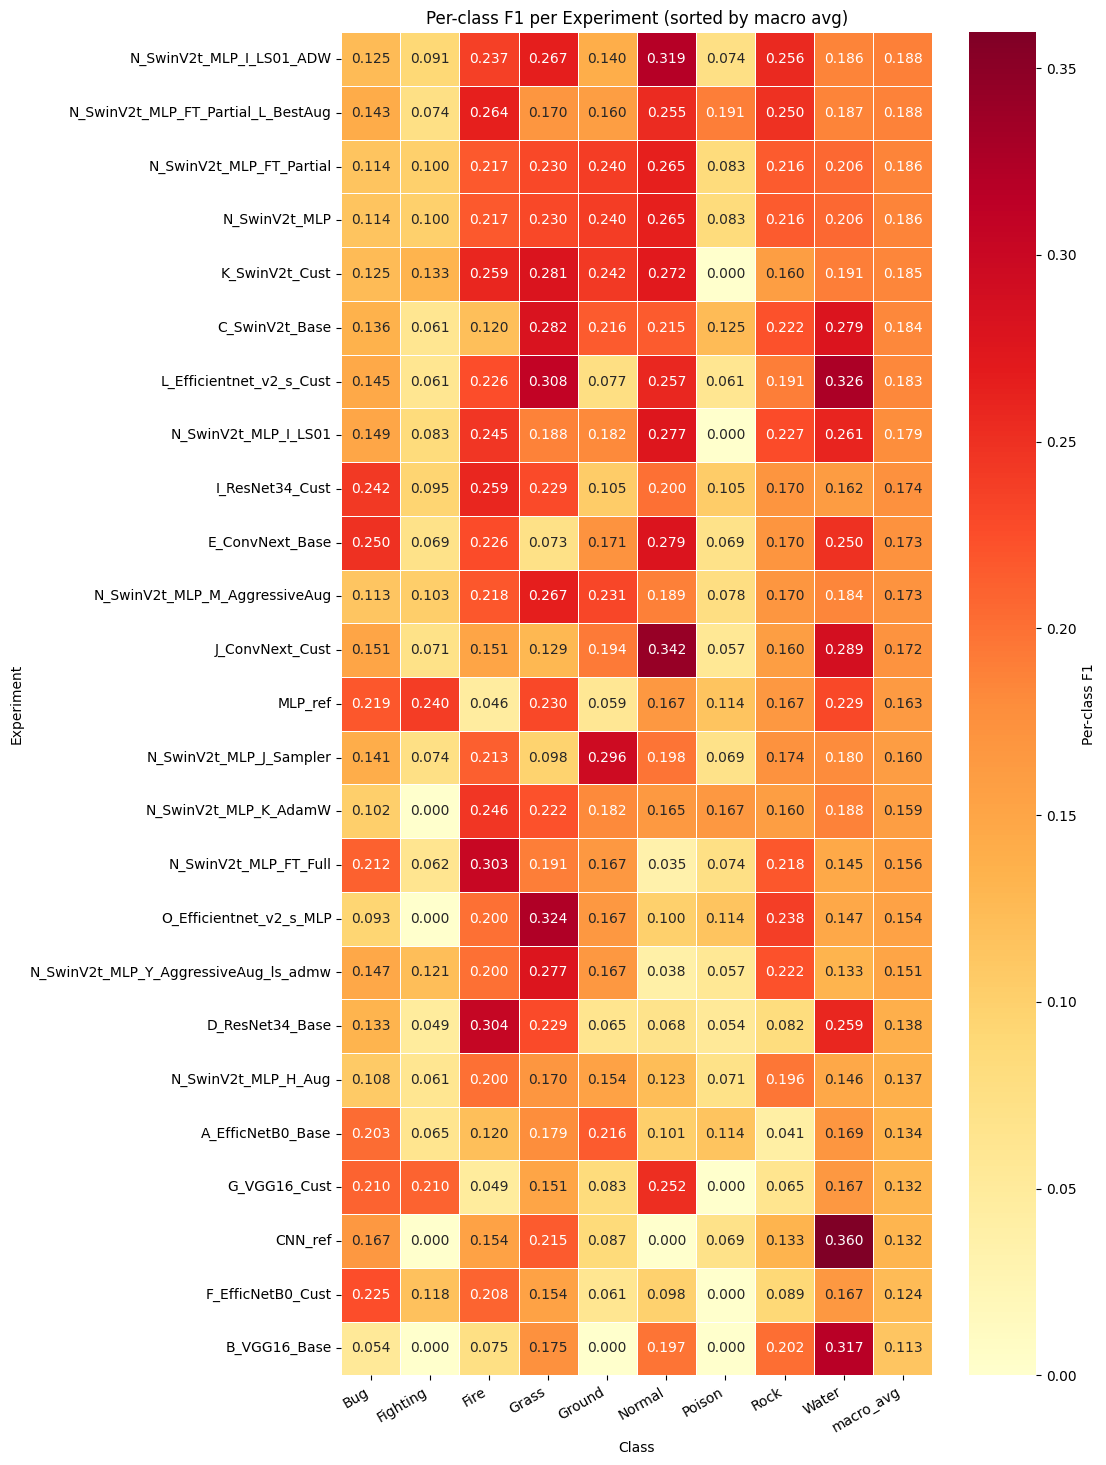

In [88]:

import matplotlib.pyplot as plt
from src.evaluation.analysis import plot_per_class_f1_heatmap

# per-class F1 heatmap: rows = models, cols = classes
# reveals which classes each backbone struggles with (e.g. Ground vs Rock confusion)
# MLP_ref and CNN_ref use 64px loaders via loader_fn_registry;
# all transfer models fall back to the default build_loaders (224px).
fig = plot_per_class_f1_heatmap(
    checkpoint_dir  = TASK_OUT_DIR / "checkpoints",
    model_registry  = {k: v["model"] for k, v in model_registry.items()},
    loader_fn       = build_loaders,
    device          = device,
    out_path        = TASK_OUT_DIR / "plots" / f"{TASK_NAME}_per_class_f1_heatmap.png",
    highlight_best  = True,
    loader_fn_registry = {
        "MLP_ref": build_loaders_64,
        "CNN_ref": build_loaders_64,
    },
)
if fig:
    plt.show()
    plt.close(fig)


### 4.2 -- Cross-Task Comparison

Progression across three levels of modelling complexity, all on the **same Pokémon-type dataset**:

| Baseline | Architecture | Image size |
|----------|-------------|-----------|
| task1 (MLP) | 3-layer MLP | 64 px (flat pixels) |
| task2 (CNN) | Custom MultiScaleCNN | 64 px |
| task3 (MLP_ref / CNN_ref) | Re-run of task1/2 best models | 64 px, same splits |
| task3 (Transfer) | Pretrained backbone + fine-tuning | 224 px, ImageNet init |

The `task3 (MLP_ref)` and `task3 (CNN_ref)` entries are the most rigorous baseline: same data splits, same FAST_RUN flag, same evaluation code as all transfer experiments — any gap vs transfer is purely architectural.

**Numbers will be replaced after the full Colab run.**

In [89]:

import json
from pathlib import Path
import pandas as pd

def _load_best(json_path, task_label):
    """Load results JSON and return a dict with the best experiment's metrics."""
    with open(json_path) as f:
        data = json.load(f)
    exps = data.get("experiments", data)   # handle both {experiments: {...}} and flat
    best_stem = max(exps, key=lambda k: exps[k]["val_macro_f1"])
    return {
        "task"        : task_label,
        "model"       : best_stem,
        "val_F1"      : round(exps[best_stem]["val_macro_f1"], 4),
        "val_acc"     : round(exps[best_stem].get("val_acc", float("nan")), 4),
        "epochs"      : exps[best_stem].get("total_epochs", "?"),
        "train_time_s": round(exps[best_stem].get("train_time_s", 0), 1),
    }

root_path = Path(ROOT)
TASK1_JSON = root_path / "task1" / "outputs" / "results" / "task1_results.json"
TASK2_JSON = root_path / "task2" / "outputs" / "results" / "task2_results.json"
TASK3_JSON = RESULTS_PATH

rows = []
for path, label in [(TASK1_JSON, "task1 (MLP)"), (TASK2_JSON, "task2 (CNN)"), (TASK3_JSON, "task3 (Transfer)")]:
    if path.exists():
        rows.append(_load_best(path, label))
    else:
        print(f"[skip] {path} not found")

# also pull MLP_ref and CNN_ref from task3's own results_tracker for a direct on-same-data comparison
for stem, label in [("MLP_ref", "task3 (MLP_ref)"), ("CNN_ref", "task3 (CNN_ref)")]:
    if stem in results_tracker:
        e = results_tracker[stem]
        rows.append({
            "task"        : label,
            "model"       : stem,
            "val_F1"      : e["val_macro_f1"],
            "val_acc"     : e["val_acc"],
            "epochs"      : e["total_epochs"],
            "train_time_s": e["train_time_s"],
        })

df_cross = pd.DataFrame(rows).set_index("task")
print("=== Cross-Task Comparison (best model per task) ===")
print(df_cross.to_string())

# delta vs task3 MLP_ref (same dataset as all task3 transfer models)
if "task3 (MLP_ref)" in df_cross.index:
    base_f1 = df_cross.loc["task3 (MLP_ref)", "val_F1"]
    print(f"\nDelta vs task3 MLP_ref baseline (same dataset, F1={base_f1:.4f}):")
    for task, row in df_cross.iterrows():
        if task != "task3 (MLP_ref)":
            d = row["val_F1"] - base_f1
            print(f"  {task:<26}  {d:+.4f}")
elif "task1 (MLP)" in df_cross.index:
    base_f1 = df_cross.loc["task1 (MLP)", "val_F1"]
    print(f"\nDelta vs task1 MLP baseline (F1={base_f1:.4f}):")
    for task, row in df_cross.iterrows():
        if task != "task1 (MLP)":
            d = row["val_F1"] - base_f1
            print(f"  {task:<26}  {d:+.4f}")

print("\n[FAST_RUN] All scores are smoke-test results only (6 samples/class, 2 epochs).")
print("Numbers will be replaced after the full Colab runs for each task.")


[skip] /content/DL_Proj/assignment_1/task1/outputs/results/task1_results.json not found
[skip] /content/DL_Proj/assignment_1/task2/outputs/results/task2_results.json not found
=== Cross-Task Comparison (best model per task) ===
                                     model  val_F1  val_acc  epochs  train_time_s
task                                                                             
task3 (Transfer)  N_SwinV2t_MLP_I_LS01_ADW  0.1883   0.2134      13         228.5
task3 (MLP_ref)                    MLP_ref  0.1634   0.1757      20         221.3
task3 (CNN_ref)                    CNN_ref  0.1316   0.1757      20         231.9

Delta vs task3 MLP_ref baseline (same dataset, F1=0.1634):
  task3 (Transfer)            +0.0249
  task3 (CNN_ref)             -0.0318

[FAST_RUN] All scores are smoke-test results only (6 samples/class, 2 epochs).
Numbers will be replaced after the full Colab runs for each task.


### 4.3 -- Ensemble Evaluation

Soft-vote ensemble of the **top-2 models** from `results_tracker` (auto-selected by val macro-F1).  
Predictions are the weighted average of per-model softmax probabilities — no re-training needed.

**[FAST_RUN] Scores are smoke-test only (6 samples/class, 2 epochs). Update after Colab run.**

> To try a custom combination, edit `ENSEMBLE_CANDIDATES` below (format: `[(stem, weight), ...]`).

In [90]:

import torch.nn.functional as F
from sklearn.metrics import f1_score as sk_f1

# ── per-stem val loader: MLP_ref/CNN_ref need 64 px, transfer models need 224 px ──
_val_64 = build_loaders_64()[1]   # 64 px val loader (computed once)

def _val_loader_for_stem(stem):
    """Return the correct val DataLoader for a given stem."""
    return _val_64 if stem in ("MLP_ref", "CNN_ref") else val_loader


def _resolve_model_constructor(stem):
    """
    Look up the model constructor for 'stem'.
    Falls back to prefix matching for derived stems like
    'D_ResNet34_Base_FT_Partial_L_BestAug' (shares arch with 'D_ResNet34_Base').
    Returns None if no match found.
    """
    if stem in model_registry:
        return model_registry[stem]["model"]
    candidates = {k: v for k, v in model_registry.items() if stem.startswith(k)}
    if candidates:
        parent_key = max(candidates, key=len)
        return model_registry[parent_key]["model"]
    return None


# ── Edit this list to try different ensemble combinations ──────────────────
# Format: (stem_name, weight)  -- stems must be in model_registry + have a checkpoint
# Example combos to try after Colab run:
#   top-2 frozen:  [("D_ResNet34_Base", 1.0), ("C_SwinV2t_Base", 1.0)]
#   frozen + FT:   [("D_ResNet34_Base", 1.0), ("D_ResNet34_Base_FT_Partial", 1.5)]
#   all Part1:     [(s, 1.0) for s in PART1_STEMS]
best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
second_best  = sorted(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"], reverse=True)
second_best  = second_best[1] if len(second_best) > 1 else best_overall

ENSEMBLE_CANDIDATES = [
    (best_overall, 1.0),
    (second_best,  1.0),
]
# ─────────────────────────────────────────────────────────────────────────────

print("Ensemble candidates:")
for stem, w in ENSEMBLE_CANDIDATES:
    f1 = results_tracker.get(stem, {}).get("val_macro_f1", "?")
    print(f"  {stem:<45}  weight={w}  val_F1={f1}")

# load each model + run its correct val loader, collect softmax probabilities
ens_probs  = None   # accumulated weighted prob sum
ens_labels = None

for stem, weight in ENSEMBLE_CANDIDATES:
    ckpt = TASK_OUT_DIR / "checkpoints" / f"{stem}.pth"
    if not ckpt.exists():
        print(f"[skip] checkpoint not found: {ckpt.name}")
        continue
    constructor = _resolve_model_constructor(stem)
    if constructor is None:
        print(f"[skip] no architecture found for stem: {stem}")
        continue

    mdl = constructor().to(device)
    mdl.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    mdl.eval()

    loader = _val_loader_for_stem(stem)   # 64 px for MLP_ref/CNN_ref, 224 px otherwise
    probs_list, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = mdl(imgs.to(device))
            probs_list.append(F.softmax(logits, dim=1).cpu())
            labels_list.extend(lbls.tolist())

    probs_tensor = torch.cat(probs_list, dim=0)  # (N, C)

    if ens_probs is None:
        ens_probs  = weight * probs_tensor
        ens_labels = labels_list
    else:
        ens_probs += weight * probs_tensor

if ens_probs is not None:
    ens_preds = ens_probs.argmax(dim=1).tolist()
    ens_f1 = sk_f1(ens_labels, ens_preds, average="macro", zero_division=0)
    single_f1 = results_tracker[best_overall]["val_macro_f1"]
    print(f"\nEnsemble val_macro_F1 : {ens_f1:.4f}")
    print(f"Best single model     : {best_overall}  F1={single_f1:.4f}")
    delta = ens_f1 - single_f1
    print(f"Delta (ensemble - single) : {delta:+.4f}  ({'ensemble wins' if delta > 0 else 'single model wins'})")
else:
    print("No valid ensemble members -- check model_registry and checkpoints.")


Ensemble candidates:
  N_SwinV2t_MLP_I_LS01_ADW                       weight=1.0  val_F1=0.1883
  N_SwinV2t_MLP_FT_Partial_L_BestAug             weight=1.0  val_F1=0.1881

Ensemble val_macro_F1 : 0.1716
Best single model     : N_SwinV2t_MLP_I_LS01_ADW  F1=0.1883
Delta (ensemble - single) : -0.0167  (single model wins)


### 4.4 -- Best Model Deep Dive

Full diagnostic on the **overall best** model by val macro-F1 (auto-selected from `results_tracker`):

1. **Training curves** — loss & accuracy over epochs (train vs val). Did the model overfit? Did early stopping trigger?
2. **Classification report** — per-class precision / recall / F1 on the full validation set.
3. **Confusion matrix** — which classes does the model confuse most? (e.g. Rock ↔ Ground)

All three artefacts are saved to `outputs/plots/`.

Best model: N_SwinV2t_MLP_I_LS01_ADW  (val_F1=0.1883)

--- Classification Report (val set) ---


,precision,recall,f1-score,support
Bug,0.170000,0.100000,0.120000,30.000000
Fighting,0.100000,0.080000,0.090000,12.000000
Fire,0.190000,0.300000,0.240000,23.000000
Grass,0.290000,0.250000,0.270000,32.000000
Ground,0.100000,0.210000,0.140000,14.000000
Normal,0.300000,0.340000,0.320000,44.000000
Poison,0.070000,0.080000,0.070000,13.000000
Rock,0.260000,0.250000,0.260000,20.000000
Water,0.230000,0.160000,0.190000,51.000000
accuracy,,,0.210000,239.000000


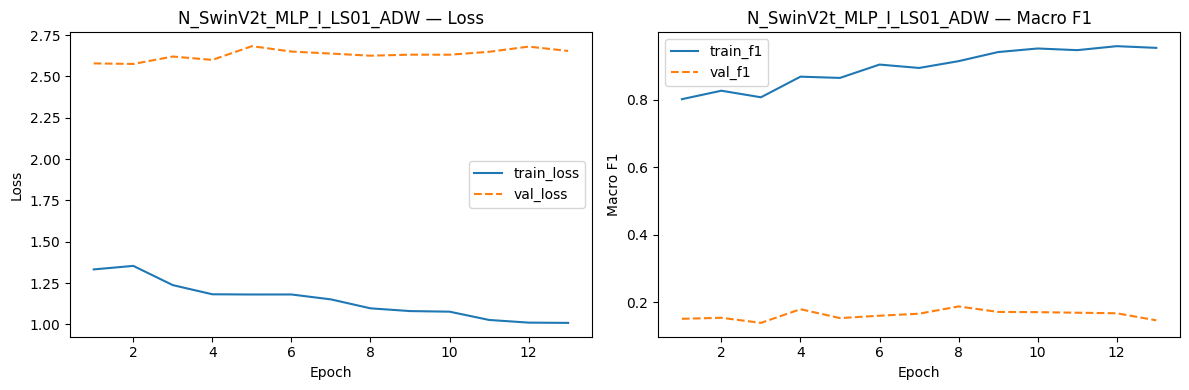

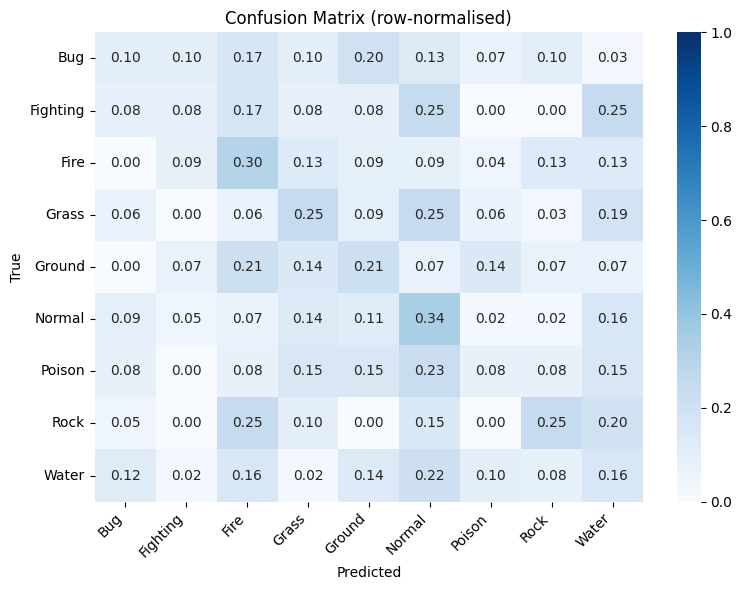

In [91]:
from src.evaluation.analysis import print_classification_report

# overall best (solo only -- no ensembles in task 3)
best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"Best model: {best_overall}  (val_F1={results_tracker[best_overall]['val_macro_f1']:.4f})")

# resolve model constructor: prefer exact registry match, then fall back to prefix matching
# (e.g. "D_ResNet34_Base_FT_Partial_L_BestAug" shares architecture with "D_ResNet34_Base")
if best_overall in model_registry:
    _best_constructor = model_registry[best_overall]["model"]
else:
    # find the longest registry key that is a prefix of the best stem
    candidates = {k: v for k, v in model_registry.items() if best_overall.startswith(k)}
    if candidates:
        parent_key = max(candidates, key=len)
        _best_constructor = candidates[parent_key]["model"]
        print(f"  [info] '{best_overall}' not in registry; using architecture from '{parent_key}'")
    else:
        raise KeyError(
            f"Cannot find architecture for '{best_overall}' in model_registry. "
            f"Re-run the experiment cells first to register derived stems, or add it manually."
        )

best_model = _best_constructor().to(device)
best_ckpt  = TASK_OUT_DIR / "checkpoints" / f"{best_overall}.pth"
best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))

# pick correct val loader: MLP_ref/CNN_ref need 64 px; transfer models need 224 px
_best_val_loader = _val_loader_for_stem(best_overall)

# classification report: precision/recall/F1 per class on val set
print("\n--- Classification Report (val set) ---")
all_labels_list, all_preds = print_classification_report(
    best_model, _best_val_loader, device, CLASSES
)

# training curves
best_history = results_tracker[best_overall]["history"]
if best_history:
    fig = plot_history(
        best_history,
        TASK_OUT_DIR / "plots" / f"{TASK_NAME}_history_{best_overall}.png",
        title=best_overall,
    )
    plt.show()
    plt.close(fig)

# confusion matrix
fig = plot_confusion_matrix(
    all_labels_list, all_preds, CLASSES,
    TASK_OUT_DIR / "plots" / f"{TASK_NAME}_confusion_{best_overall}.png",
)
plt.show()
plt.close(fig)


### 4.5 -- Final Submission

Run the overall best model on the **held-out test set** and write the Kaggle submission CSV.

- The correct test loader is selected automatically (`64 px` for MLP_ref/CNN_ref, `224 px` for transfer models) via `_make_test_loader`.
- `run_experiment` cells already auto-generate a submission when a new best is found — this cell is a **final confirmation / explicit re-run** in case the checkpoint was updated after the last auto-save.

In [ ]:
# F -- Partial fine-tune: unfreeze last 1 backbone block + differential LR.
# Starts from Stage-1 checkpoint -- head is already converged, gradients stable.
ft_partial_stem = f"{best_frozen}_FT_Partial"

model_F = model_registry[best_frozen]["model"]().to(device)
model_F.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=1: unfreeze last 1 top-level backbone block only
# prints exact trainable/total count so we know how much of the backbone is now live
unfreeze_backbone(model_F, n_layers=1)

# differential LR: backbone gets 1e-5 (tiny nudge), head keeps normal LR
optimizer_F  = torch.optim.Adam(get_backbone_lr_groups(model_F, backbone_lr=1e-5, head_lr=LR))
criterion_F  = nn.CrossEntropyLoss(weight=class_weights)
# ReduceLROnPlateau fires on val stagnation -- coherent with early stopping (no fixed-epoch steps)
scheduler_F  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_F, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_F, history_F = run_experiment(
    model_F, ft_partial_stem, criterion_F, optimizer_F, scheduler_F, loaders_base,
)
# register so Part 4 ensemble / heatmap cells can find it by stem
model_registry[ft_partial_stem] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

In [ ]:
# H -- frozen backbone + transfer augmentation.
# Everything identical to the Part 1 baseline except train loader uses aug transforms.
stem_H = f"{best_frozen}_H_Aug"
PART3_STEMS.append(stem_H)

model_H = model_registry[best_frozen]["model"]().to(device)
model_H.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# backbone stays fully frozen -- only the linear head is trainable (same as Part 1)
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
criterion_H = nn.CrossEntropyLoss(weight=class_weights)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=10, gamma=0.5)

# loaders_aug: transfer_aug=True -> gentle flip/rotation/colour jitter at 224px
model_H, history_H = run_experiment(
    model_H, stem_H, criterion_H, optimizer_H, scheduler_H, loaders_aug
)
model_registry[stem_H] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

In [ ]:
stem_Z = f"{best_frozen}_I_LS01_ADW"
PART3_STEMS.append(stem_z)

model_Z = model_registry[best_frozen]["model"]().to(device)
model_Z.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_Z = torch.optim.AdamW(model_Z.parameters(), lr=LR, weight_decay=0.01)
# label_smoothing=0.1: soft targets prevent overconfidence on small dataset
criterion_Z = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_Z = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=10, gamma=0.5)

# base loaders -- same as Part 1 (no aug, no sampler), isolates LS effect
model_Z, history_Z = run_experiment(
    model_Z, stem_Z, criterion_Z, optimizer_Z, scheduler_Z, loaders_base
)
model_registry[stem_Z] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

In [92]:

# Final submission: run best model on test set and write CSV.
# _make_test_loader returns test_loader_64 for MLP_ref/CNN_ref, test_loader (224 px) otherwise.
# _resolve_model_constructor handles derived stems (e.g. FT+aug combos) via prefix matching.

best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"Generating submission for: {best_overall}  (val_F1={results_tracker[best_overall]['val_macro_f1']:.4f})")

# load best checkpoint (prefix-match fallback for derived stems)
constructor = _resolve_model_constructor(best_overall)
if constructor is None:
    raise KeyError(
        f"Cannot resolve architecture for '{best_overall}'. "
        "Re-run experiment cells to populate model_registry, or add the stem manually."
    )
final_model = constructor().to(device)
final_ckpt  = TASK_OUT_DIR / "checkpoints" / f"{best_overall}.pth"
final_model.load_state_dict(torch.load(final_ckpt, map_location=device, weights_only=True))
final_model.eval()

# select correct test loader (64 px vs 224 px)
final_tl = _make_test_loader(best_overall)
print(f"Using {'64 px' if best_overall in ('MLP_ref', 'CNN_ref') else '224 px'} test loader")

# collect test predictions
test_preds = []
with torch.no_grad():
    for imgs, _ in final_tl:
        test_preds.extend(final_model(imgs.to(device)).argmax(dim=1).cpu().tolist())

generate_submission_from_preds(final_tl, test_preds, CLASSES, SUB_PATH)
validate_submission(SUB_PATH)
print(f"Submission saved ({len(test_preds)} rows) -> {SUB_PATH}")


Generating submission for: N_SwinV2t_MLP_I_LS01_ADW  (val_F1=0.1883)
Using 224 px test loader
Submission saved: task3/outputs/results/submission_task3.csv  (300 rows)
Submission valid: 300 rows, all class names correct.
Submission saved (300 rows) -> task3/outputs/results/submission_task3.csv


## 4.6 -- Save Outputs

Persists all artefacts from this run to Drive (Colab) or prints the local output paths.

- **Colab + Drive:** zips `task3/outputs/` and writes to `DRIVE_OUTPUTS_DIR` in your MyDrive.
- **Colab without Drive:** zips and triggers a browser download via `google.colab.files`.
- **Local:** prints paths to checkpoints, results JSON, and submission CSV (already on disk).

In [ ]:
# # Save final outputs to Drive (Colab) or create a local zip for download.
# if USE_DRIVE:
#     save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)
# elif IN_COLAB:
#     # running on Colab without Drive -- zip + download directly
#     import shutil
#     from google.colab import files
#     zip_path = str(TASK_OUT_DIR) + ".zip"
#     shutil.make_archive(str(TASK_OUT_DIR), "zip", TASK_OUT_DIR)
#     files.download(zip_path)
#     print(f"Downloading {zip_path}")
# else:
#     # local run -- outputs are already in TASK_OUT_DIR
#     print(f"[save_outputs] Local run -- outputs at: {TASK_OUT_DIR}")
#     print(f"  Checkpoints : {list((TASK_OUT_DIR / 'checkpoints').glob('*.pth'))}")
#     print(f"  Results JSON: {RESULTS_PATH}  (exists: {RESULTS_PATH.exists()})")
#     print(f"  Submission  : {SUB_PATH}  (exists: {SUB_PATH.exists()})")
